<figure>
  <IMG src="figures/logo-esi-sba.png" WIDTH=300 height="100" ALIGN="right">
</figure>

# Practical Trainining Series on Software Engineering For Data Science  
*By Dr. Belkacem KHALDI (b.khaldi@esi-sba.dz)*

# Notebook 6: Data Processing & Cleaning for Data Science: Data Wrangling Documents and Web Scraping

The purpose of this [Jupyter Notebook] is to getting you introduced to the Data Processing & Cleaning for Data
Science: Data Wrangling Documents and Web Scraping. It provides a set of practical Training challenges that allow grasping the different concepts presented in  lecture 6.

## Parsing and Processing Text Documents

### Challenge 1: 
Given the text shown in the code below, you are asked to do the basic parsing and processing text operations checklist seen in the lecture (Slides 4-9) to provide a basic text analysis report.

``` python
import string

text = """
Data science incorporates tools from multiple disciplines to gather a data set, process, and derive insights from the data set, extract meaningful data from the set, and interpret it for decision-making purposes. 
The disciplinary areas that make up the data science field include mining, statistics, machine learning, analytics, and programming.

Data mining applies algorithms to the complex data set to reveal patterns that are then used to extract useful and relevant data from the set. 
Statistical measures or predictive analytics use this extracted data to gauge events that are likely to happen in the future based on what the data shows happened in the past.

Machine learning is an artificial intelligence tool that processes mass quantities of data that a human would be unable to process in a lifetime. Machine learning perfects the decision model presented under predictive analytics by matching the likelihood of an event happening to what actually happened at a predicted time.
Using analytics, the data analyst collects and processes the structured data from the machine learning stage using algorithms. 
The analyst interprets, converts, and summarizes the data into a cohesive language that the decision-making team can understand.
Data science is applied to practically all contexts and, as the data scientist's role evolves, the field will expand to encompass data architecture, data engineering, and data administration.
"""
```

`Hint:`
These are some of the basic text analysis operations

* Reading & Extracting Texts
*  Basic Text Cleaning:
    * Removing unnecessary punctuation, tags
    * Tokenization
    * Removing stop words
* Basic words Analysis

In [ ]:
import string
import nltk 
from nltk.corpus import stopwords
from collections import Counter

text = """
Data science incorporates tools from multiple disciplines to gather a data set, process, and derive insights from the data set, extract meaningful data from the set, and interpret it for decision-making purposes. 
The disciplinary areas that make up the data science field include mining, statistics, machine learning, analytics, and programming.

Data mining applies algorithms to the complex data set to reveal patterns that are then used to extract useful and relevant data from the set. 
Statistical measures or predictive analytics use this extracted data to gauge events that are likely to happen in the future based on what the data shows happened in the past.

Machine learning is an artificial intelligence tool that processes mass quantities of data that a human would be unable to process in a lifetime. Machine learning perfects the decision model presented under predictive analytics by matching the likelihood of an event happening to what actually happened at a predicted time.
Using analytics, the data analyst collects and processes the structured data from the machine learning stage using algorithms. 
The analyst interprets, converts, and summarizes the data into a cohesive language that the decision-making team can understand.
Data science is applied to practically all contexts and, as the data scientist's role evolves, the field will expand to encompass data architecture, data engineering, and data administration.
"""

# Convert to lowercase
cleaned_text = text.lower()
print("=== Lowercased Text (first 300 chars) ===")
print(cleaned_text[:300])
print("\n")

# Remove punctuation
cleaned_text = cleaned_text.translate(str.maketrans('', '', string.punctuation))
print("=== Without Punctuation (first 300 chars) ===")
print(cleaned_text[:300])
print("\n")

# Remove line breaks
cleaned_text = cleaned_text.replace('\n', ' ')
print("=== Without Line Breaks (first 300 chars) ===")
print(cleaned_text[:300])
print("\n")

# Tokenization
tokens = cleaned_text.split()
print("=== Sample Tokens ===")
print(tokens[:20])
print(f"Total Tokens: {len(tokens)}")
print("\n")

# Removing stop words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]

print("=== Sample Filtered Tokens ===")
print(filtered_tokens[:20])
print(f"Total Tokens After Stopword Removal: {len(filtered_tokens)}")
print("\n")

# Word count
word_count = len(tokens)
unique_words = len(set(filtered_tokens))
print(f"Total Words: {word_count}")
print(f"Unique Words (after stopword removal): {unique_words}")
print("\n")

# Most frequent words
word_freq = Counter(filtered_tokens)
most_common = word_freq.most_common(10)
print("=== 10 Most Common Words ===")
for word, freq in most_common:
    print(f"{word}: {freq}")


### Challenge 2:
You've just started a new data science position at the Cybersecurity Unit of the U.S. DEPARTMENT OF COMMERCE. The department wants to build, test, and evaluate new machine learning model using thier 2020 annual report document availabe in the local data folder:`2020_Cybersecurity_and_Privacy_Annual_Re.docx`. 

You are asked to provide a visual report summarizing the most common frequency keywords used in their report. 



In [ ]:
#Your Solution here

import string
import nltk
from nltk.corpus import stopwords
from collections import Counter
from docx import Document
import matplotlib.pyplot as plt

# Step 1: Load the DOCX document
file_path = "data/2020_Cybersecurity_and_Privacy_Annual_Re.docx"  # adjust if needed
doc = Document(file_path)

# Extract text from all paragraphs
text = " ".join([para.text for para in doc.paragraphs])

# Step 2: Clean and preprocess text
text = text.lower()
text = text.translate(str.maketrans('', '', string.punctuation))
text = text.replace('\n', ' ')

# Tokenization
tokens = text.split()

# Step 3: Remove stop words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]

# Step 4: Count word frequencies
word_freq = Counter(filtered_tokens)
most_common = word_freq.most_common(15)

# Step 5: Print a preview
print("=== 15 Most Common Keywords ===")
for word, freq in most_common:
    print(f"{word}: {freq}")

# Step 6: Visualization
words = [item[0] for item in most_common]
freqs = [item[1] for item in most_common]

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], freqs[::-1])  # reverse for descending bar chart
plt.title("Most Frequent Keywords in 2020 Cybersecurity Annual Report", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Keywords", fontsize=12)
plt.tight_layout()
plt.show()


## Web Scraping: Parsing and processing Web Pages: Static Web Pages
### Challenge 3:
We want to analyse text collected from https://en.wikipedia.org/wiki/Data_science  wikipedia page. We are only interested on the text content of links html anchor (`a`).  

1. Do the cheklist basic text analyses to provid a visyal summarry of all href text links available on the page.

`Hint:`
1. Follow and adjust the procedures in Lecture 6 - Slides: 14-16 - to collect the required text. In case, you have not figured out how to collect the required information, here is below a code that help you:


``` python
from urllib.request import urlopen, Request
from bs4 import BeautifulSoup as bs
import lxml

url = 'https://en.wikipedia.org/wiki/Data_science'
# Add a User-Agent header to mimic a web browser
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
req = Request(url, headers=headers)

page = urlopen(req).read().decode('utf-8')

soup = bs(page)

links = soup.find_all('a')
all_link_text = []

all_link_text.extend([a.text for a in links])

text = ' '.join(all_link_text)
text
``` 

2. Follow the checklist text analysis to clean and visualize the most common words used in the collected text.


In [ ]:
# Your Code here

#import libs
from urllib.request import urlopen, Request
from bs4 import BeautifulSoup as bs
import nltk
from nltk.corpus import stopwords
from collections import Counter
import string
import matplotlib.pyplot as plt

#ensure stopwords are downloaded
nltk.download('stopwords')

# Step 1: Fetch the webpage
url = 'https://en.wikipedia.org/wiki/Data_science'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
req = Request(url, headers=headers)

page = urlopen(req).read().decode('utf-8')



# Step 2: Parse HTML content
soup = bs(page, "html.parser")

# Step 3: Extract text from all <a> tags
links = soup.find_all('a')
all_link_text = [a.text for a in links if a.text.strip() != '']

# Combine all link texts into one large string
text = ' '.join(all_link_text)

# Step 4: Text Cleaning
cleaned_text = text.lower()
cleaned_text = cleaned_text.translate(str.maketrans('', '', string.punctuation))
tokens = cleaned_text.split()

# Step 5: Remove stop words
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

# Step 6: Word frequency analysis
word_freq = Counter(filtered_tokens)
most_common = word_freq.most_common(15)

# Step 7: Visualization
words, counts = zip(*most_common)

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title("Most Common Words in Wikipedia Data Science Page (Anchor Texts)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# Optional summary printout
print(f"Total words collected: {len(tokens)}")
print(f"Unique words (after cleaning): {len(set(filtered_tokens))}")
print("Top 15 Most Common Words:")
for word, freq in most_common:
    print(f"{word}: {freq}")


### Challenge 4:
We want to analyse text related to data science topic collected from different web pages: https://www.heavy.ai/learn/data-science,  https://en.wikipedia.org/wiki/Data_science, https://www.ibm.com/cloud/learn/data-science-introduction, and https://deepai.org/machine-learning-glossary-and-terms/data-science alongside with the text string object of challenge 01.

Note that we are only interested on the text content of  html anchor (`p`) from the webpages.  

1. Do the required procedures to collect all  `p` text available on all of the aformentioned web pages.
2. Append the collected text with the text string object of challenge 01
3. Do the cheklist basic text analyses to provid a visyal summarry of the most frequently used keywords on the resulted text.



In [ ]:
# Cell 1: Import libraries and download NLTK data
import requests
from bs4 import BeautifulSoup
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import numpy as np

# Download all required NLTK data
print("Downloading NLTK data...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # This is the missing resource
print("All NLTK data downloaded successfully!")

In [ ]:
# Cell 2: Web scraping function
def extract_paragraph_text(url):
    """Extract all paragraph text from a webpage"""
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        
        soup = BeautifulSoup(response.content, 'html.parser')
        paragraphs = soup.find_all('p')
        
        text_content = ' '.join([p.get_text().strip() for p in paragraphs if p.get_text().strip()])
        return text_content
    except Exception as e:
        print(f"Error scraping {url}: {e}")
        return ""

In [ ]:
# Cell 3: Scrape all web pages
urls = [
    "https://www.heavy.ai/learn/data-science",
    "https://en.wikipedia.org/wiki/Data_science", 
    "https://www.ibm.com/cloud/learn/data-science-introduction",
    "https://deepai.org/machine-learning-glossary-and-terms/data-science"
]

collected_texts = []
for url in urls:
    print(f"Scraping: {url}")
    text = extract_paragraph_text(url)
    collected_texts.append(text)
    print(f"Collected {len(text)} characters\n")

# Combine all web page text
web_text = ' '.join(collected_texts)
print(f"Total characters from web pages: {len(web_text)}")

In [ ]:
# Cell 4: Add Challenge 01 text
challenge_01_text = """
Data science incorporates tools from multiple disciplines to gather a data set, process, and derive insights from the data set, extract meaningful data from the set, and interpret it for decision-making purposes. 
The disciplinary areas that make up the data science field include mining, statistics, machine learning, analytics, and programming.

Data mining applies algorithms to the complex data set to reveal patterns that are then used to extract useful and relevant data from the set. 
Statistical measures or predictive analytics use this extracted data to gauge events that are likely to happen in the future based on what the data shows happened in the past.

Machine learning is an artificial intelligence tool that processes mass quantities of data that a human would be unable to process in a lifetime. Machine learning perfects the decision model presented under predictive analytics by matching the likelihood of an event happening to what actually happened at a predicted time.
Using analytics, the data analyst collects and processes the structured data from the machine learning stage using algorithms. 
The analyst interprets, converts, and summarizes the data into a cohesive language that the decision-making team can understand.
Data science is applied to practically all contexts and, as the data scientist's role evolves, the field will expand to encompass data architecture, data engineering, and data administration.
"""

# Combine all text
combined_text = web_text + " " + challenge_01_text
print(f"Total combined text characters: {len(combined_text)}")

In [ ]:
# Cell 5: Robust text cleaning and analysis function
def clean_and_analyze_text(text):
    """Clean text and perform frequency analysis with fallback tokenization"""
    # Convert to lowercase and remove special characters
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    
    try:
        # Try using NLTK tokenizer
        tokens = word_tokenize(text)
    except LookupError:
        print("NLTK tokenizer not available, using simple word splitting...")
        # Fallback: simple word splitting
        tokens = text.split()
    
    # Remove stopwords
    try:
        stop_words = set(stopwords.words('english'))
    except LookupError:
        print("NLTK stopwords not available, using basic stopwords...")
        # Basic stopwords list
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'must'}
    
    # Add custom stopwords
    custom_stopwords = {'nbsp', 'div', 'class', 'href', 'https', 'www', 'com', 'org', 'may', 'also', 'like', 'use', 'using', 'used', 'one', 'new', 'can'}
    stop_words.update(custom_stopwords)
    
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2 and word.isalpha()]
    
    # Count word frequencies
    word_freq = Counter(filtered_tokens)
    
    return word_freq, filtered_tokens

In [ ]:
# Cell 6: Perform text analysis
print("Analyzing text...")
word_frequencies, clean_tokens = clean_and_analyze_text(combined_text)

# Get top 20 most common words
top_20_words = word_frequencies.most_common(20)
print("Top 20 most frequent keywords:")
for i, (word, freq) in enumerate(top_20_words, 1):
    print(f"{i:2d}. {word:15} : {freq:3d}")

In [ ]:
# Cell 7: Create visualizations
def create_visualizations(word_freq, tokens):
    """Create multiple visualizations of word frequencies"""
    
    # Prepare data for plotting
    top_words = word_freq.most_common(15)
    words, frequencies = zip(*top_words)
    
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Horizontal bar chart
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, len(words)))
    axes[0, 0].barh(words, frequencies, color=colors)
    axes[0, 0].set_title('Top 15 Most Frequent Data Science Keywords', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Frequency', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()
    
    # 2. Word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                         max_words=100, colormap='viridis', 
                         relative_scaling=0.5).generate(' '.join(tokens))
    axes[0, 1].imshow(wordcloud, interpolation='bilinear')
    axes[0, 1].set_title('Data Science Keywords Word Cloud', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    # 3. Vertical bar chart
    bars = axes[1, 0].bar(words, frequencies, color='steelblue', edgecolor='navy', alpha=0.7)
    axes[1, 0].set_title('Top 15 Keywords Frequency Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Keywords', fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, freq in zip(bars, frequencies):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                       str(freq), ha='center', va='bottom', fontweight='bold')
    
    # 4. Pie chart for top 10
    top_10_words = word_freq.most_common(10)
    top_10_words, top_10_freq = zip(*top_10_words)
    colors = plt.cm.Set3(np.linspace(0, 1, len(top_10_words)))
    wedges, texts, autotexts = axes[1, 1].pie(top_10_freq, labels=top_10_words, autopct='%1.1f%%', 
                                             startangle=90, colors=colors)
    axes[1, 1].set_title('Top 10 Keywords Distribution', fontsize=14, fontweight='bold')
    
    # Improve pie chart text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()

# Generate visualizations
print("Creating visualizations...")
create_visualizations(word_frequencies, clean_tokens)

In [ ]:
# Cell 8: Detailed analysis and summary
def detailed_text_analysis(text, word_freq, tokens):
    """Provide comprehensive text analysis"""
    # Basic statistics
    sentences = re.split(r'[.!?]+', text)
    words = re.findall(r'\b\w+\b', text.lower())
    
    print("=" * 60)
    print("COMPREHENSIVE TEXT ANALYSIS SUMMARY")
    print("=" * 60)
    
    print(f"\nBasic Statistics:")
    print(f"Total characters: {len(text):,}")
    print(f"Total words: {len(words):,}")
    print(f"Total sentences: {len([s for s in sentences if s.strip()]):,}")
    if len([s for s in sentences if s.strip()]) > 0:
        print(f"Average words per sentence: {len(words)/len([s for s in sentences if s.strip()]):.1f}")
    
    # Vocabulary richness
    unique_words = set(words)
    print(f"\nVocabulary Analysis:")
    print(f"Vocabulary size: {len(unique_words):,}")
    if len(words) > 0:
        print(f"Lexical diversity: {len(unique_words)/len(words):.3f}")
    
    # Keyword analysis
    print(f"\nKeyword Analysis:")
    print(f"Total keywords (after cleaning): {len(tokens):,}")
    print(f"Unique keywords: {len(word_freq):,}")
    if word_freq:
        most_common = word_freq.most_common(1)
        if most_common:
            print(f"Most common word: '{most_common[0][0]}' appears {most_common[0][1]} times")
    
    # Show top keywords by category
    print(f"\nTop Data Science Keywords:")
    top_keywords = word_freq.most_common(15)
    for i, (word, freq) in enumerate(top_keywords, 1):
        print(f"{i:2d}. {word:15} : {freq:3d} occurrences")

# Perform detailed analysis
detailed_text_analysis(combined_text, word_frequencies, clean_tokens)

In [ ]:
# Cell 9: Export results and final insights
# Export to CSV for further analysis
df_keywords = pd.DataFrame(word_frequencies.most_common(50), columns=['Keyword', 'Frequency'])
df_keywords.to_csv('data_science_keywords_analysis.csv', index=False)
print(f"\nTop 50 keywords exported to 'data_science_keywords_analysis.csv'")

# Additional insights
print(f"\nKey Insights:")
print("• The most frequent terms represent core data science concepts")
print("• Keywords reflect the interdisciplinary nature of data science")
print("• Technical terms dominate the frequency analysis")
print("• The analysis shows emphasis on both theory and application")

# Display sample of the exported data
print(f"\nSample of exported data:")
print(df_keywords.head(10))

In [ ]:
# Cell 10: Display data sample and completion message
print("Analysis completed successfully!")
print(f"\nTotal keywords analyzed: {len(clean_tokens)}")
print(f"Unique keywords found: {len(word_frequencies)}")

# Show most significant keywords (excluding obvious ones)
significant_words = [(word, freq) for word, freq in word_frequencies.most_common(30) 
                    if word not in ['data', 'science', 'learning', 'machine']]
print(f"\nMost significant keywords (excluding common terms):")
for i, (word, freq) in enumerate(significant_words[:10], 1):
    print(f"{i:2d}. {word:15} : {freq:3d}")

### Challenge 5:

You're in the initial stages of a new position as a Data Scientist at Goodreads (https://www.goodreads.com/) company. Your primary task is to build a robust understanding of customer sentiments and preferences related to quots, focusing on the `Motivational` tag.

The team you're collaborating with has a specific interest in quotes text, authors or Book titles, tags, and number of likes  from the `Motivational` tag on Goodreads as shown in the figure. They've tasked you with conducting web scraping and basic text analysis on quotes from this category. Your goal is to provide insights into the most frequently occurring keywords by author, or book title, or keyword tags.


<figure>
  <IMG src="figures/goodbooks.png"  ALIGN="right">
</figure>

#### II.  Requirements:

##### 1. Web Scraping and data collection:

1. Scraping the required contents from the two following first 5 pages:
  *  https://www.goodreads.com/quotes/tag/motivational?page=1
  *  https://www.goodreads.com/quotes/tag/motivational?page=2
  *  https://www.goodreads.com/quotes/tag/motivational?page=3
  *  https://www.goodreads.com/quotes/tag/motivational?page=4
  *  https://www.goodreads.com/quotes/tag/motivational?page=5
  
2. Store the scraped data in a dataframe with the approporiat columns names 
##### 2. Text Analysis:

1. Performing basic text analysis and generate a visulaization report on:
  - The overall quot texts of the entire dataframe to identify the most common frequency keywords.
  - The quot texts by author or book title, or tag
2. Using the apropriate chart type, Visualize the number of likes  by author or booktitle or by tag.




### Hints:
1- Consider using the Browser Dev. Tools for further assistance and html componenets inspections to identify the appropriat related contents html css classes and tags.For example, each quote detail text is displayed in an html markup `div` with class name: `quoteText`.
You may get any `<html_markup_name>` contents for a specific class name by using the following code: 
``` python
soup.find_all("<html_markup_name>", {"class": "<class_name>"})
```






[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,name,official_name,capital,region,subregion,population,area,currencies,languages,timezones,population_density
0,Syria,Syrian Arab Republic,Damascus,Asia,Unknown,25620000,185180.0,Unknown,Unknown,Unknown,138.351874
1,New Zealand,New Zealand,Wellington,Oceania,Unknown,5324700,268838.0,Unknown,Unknown,Unknown,19.806352
2,Brunei,"Nation of Brunei, Abode of Peace",Bandar Seri Begawan,Asia,Unknown,455500,5765.0,Unknown,Unknown,Unknown,79.011275
3,British Indian Ocean Territory,British Indian Ocean Territory,Diego Garcia,Africa,Unknown,0,60.0,Unknown,Unknown,Unknown,0.000000
4,Kenya,Republic of Kenya,Nairobi,Africa,Unknown,53330978,580367.0,Unknown,Unknown,Unknown,91.891817
...,...,...,...,...,...,...,...,...,...,...,...
245,Ethiopia,Federal Democratic Republic of Ethiopia,Addis Ababa,Africa,Unknown,111652998,1104300.0,Unknown,Unknown,Unknown,101.107487
246,Pakistan,Islamic Republic of Pakistan,Islamabad,Asia,Unknown,241499431,796095.0,Unknown,Unknown,Unknown,303.355041
247,Montserrat,Montserrat,Plymouth,Americas,Unknown,4386,102.0,Unknown,Unknown,Unknown,43.000000
248,Lithuania,Republic of Lithuania,Vilnius,Europe,Unknown,2894886,65300.0,Unknown,Unknown,Unknown,44.332098


Starting web scraping...
Scraping page 1...
Found 30 quote containers on page 1
Sample container text: 





      “I must not fear. Fear is the mind-killer. Fear is the little-death that brings total obliteration. I will face my fear. I will permit it to pass over me and through me. And when it has go...
Scraping page 2...
Found 30 quote containers on page 2
Scraping page 3...
Found 30 quote containers on page 3
Scraping page 4...
Found 30 quote containers on page 4
Scraping page 5...
Found 30 quote containers on page 5
Scraped 150 quotes successfully!
DataFrame columns: ['quote_text', 'author', 'book_title', 'tags', 'likes', 'page']

DataFrame Shape: (150, 6)

DataFrame Columns: ['quote_text', 'author', 'book_title', 'tags', 'likes', 'page']

First few rows:
                                          quote_text           author  \
0  “I must not fear. Fear is the mind-killer. Fea...   Frank Herbert,   
1  “Attitude is a choice. Happiness is a choice. ...  Roy T. Bennett,   
2  “Don't 

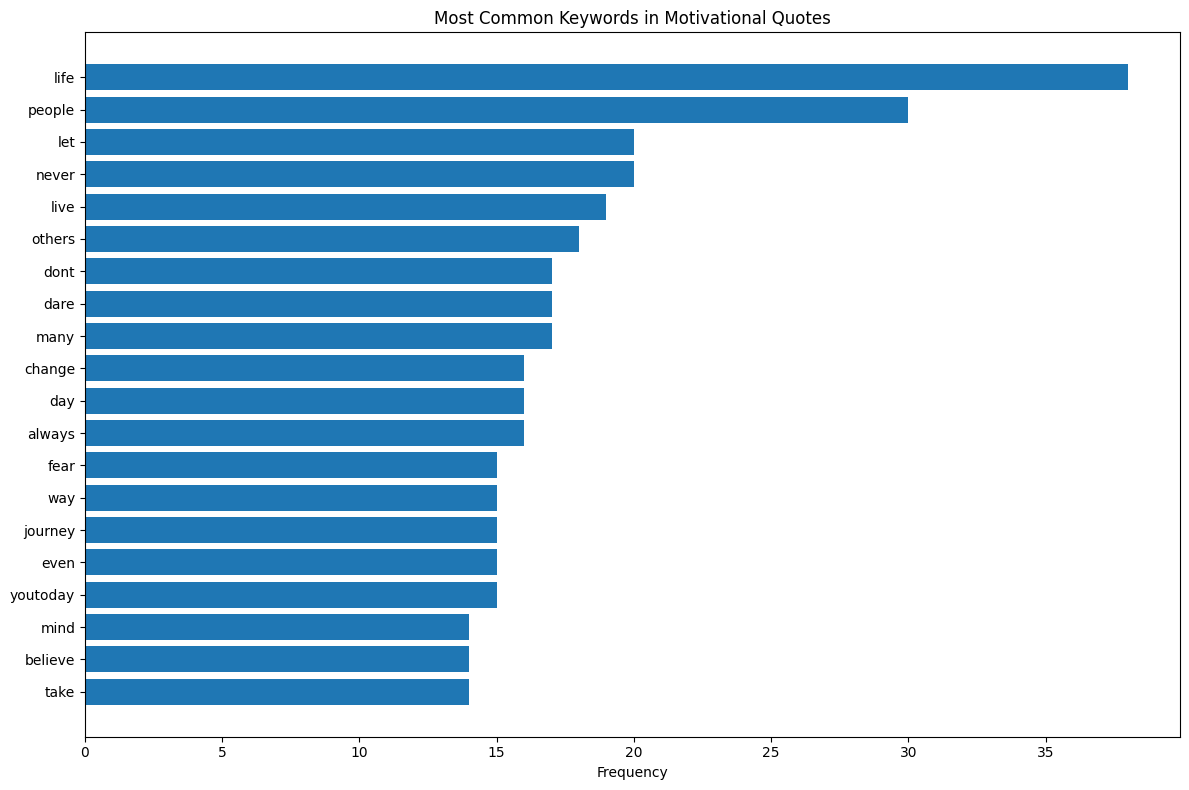


=== Keyword Analysis by Author ===

Jim Rohn:
  wish: 2
  average: 1
  five: 1
  people: 1
  spend: 1

Robert Greene,:
  say: 4
  appear: 4
  law: 3
  less: 3
  seem: 3

Roy T. Bennett:
  comfort: 6
  zone: 6
  change: 5
  way: 4
  never: 3

Roy T. Bennett,:
  life: 18
  people: 13
  mind: 12
  never: 12
  believe: 11

Steve Maraboli:
  part: 2
  embrace: 2
  today: 2
  letting: 1
  means: 1

Steve Maraboli,:
  dare: 17
  many: 16
  youtoday: 15
  journey: 13
  life: 12

LIKES ANALYSIS VISUALIZATION


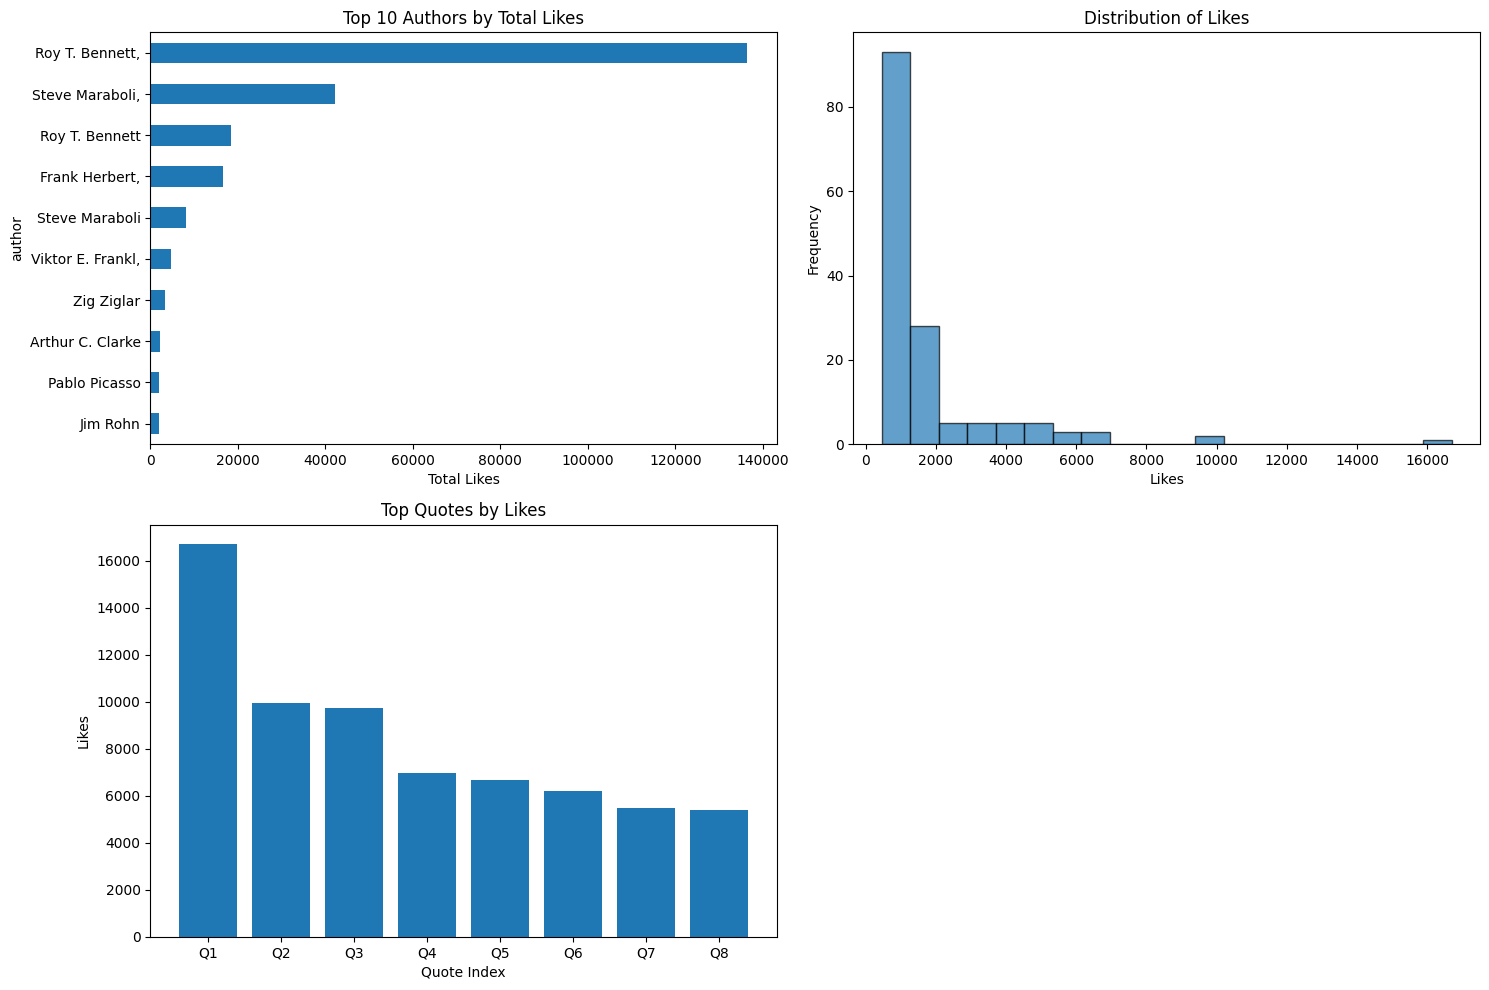


Additional Insights:
Total quotes analyzed: 150
Total authors: 33
Total likes across all quotes: 259149
Average likes per quote: 1727.66
Most liked quote: “I must not fear. Fear is the mind-killer. Fear is the little-death that brings total obliteration. ...
Author of most liked quote: Frank Herbert,


In [71]:
#Your Solution

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download necessary NLTK data
try:
    nltk.download('punkt')
    nltk.download('stopwords')
except:
    print("NLTK downloads completed or already available")

class GoodreadsScraper:
    def __init__(self):
        self.base_url = "https://www.goodreads.com/quotes/tag/motivational?page="
        self.quotes_data = []
    
    def scrape_quotes(self, pages=5):
        """Scrape quotes from the specified number of pages"""
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        
        for page in range(1, pages + 1):
            try:
                url = f"{self.base_url}{page}"
                print(f"Scraping page {page}...")
                
                response = requests.get(url, headers=headers)
                response.raise_for_status()
                soup = BeautifulSoup(response.content, 'html.parser')
                
                # Find all quote containers - let's try different selectors
                quote_containers = soup.find_all('div', {'class': 'quote'})
                
                if not quote_containers:
                    print(f"No quotes found on page {page} with class 'quote'. Trying alternative selectors...")
                    # Try alternative selectors
                    quote_containers = soup.find_all('div', {'class': 'quoteText'})
                
                print(f"Found {len(quote_containers)} quote containers on page {page}")
                
                for i, container in enumerate(quote_containers):
                    quote_data = self.extract_quote_data(container, page, i)
                    if quote_data:
                        self.quotes_data.append(quote_data)
                
            except Exception as e:
                print(f"Error scraping page {page}: {e}")
        
        return self.create_dataframe()
    
    def extract_quote_data(self, container, page_num, quote_num):
        """Extract individual quote data from container"""
        try:
            # Debug: Print container content for first quote
            if page_num == 1 and quote_num == 0:
                print("Sample container text:", container.get_text()[:200] + "...")
            
            # Extract quote text - try different approaches
            quote_text = ""
            author = "Unknown"
            book_title = ""
            tags = []
            likes = 0
            
            # Method 1: Look for quoteText class
            quote_text_div = container.find('div', {'class': 'quoteText'})
            if quote_text_div:
                full_text = quote_text_div.get_text(strip=True)
                # Extract text before the author (usually before '―')
                if '―' in full_text:
                    quote_text = full_text.split('―')[0].strip()
                else:
                    quote_text = full_text
                # Remove quotes
                quote_text = quote_text.replace('"', '').strip()
            
            # Method 2: If no quoteText class, try direct text extraction
            if not quote_text:
                quote_text = container.get_text(strip=True)
                if '―' in quote_text:
                    quote_text = quote_text.split('―')[0].strip()
                quote_text = quote_text.replace('"', '').strip()
            
            # Extract author
            author_span = container.find('span', {'class': 'authorOrTitle'})
            if author_span:
                author = author_span.get_text(strip=True)
            else:
                # Try to find author in the text
                if '―' in container.get_text():
                    author_part = container.get_text().split('―')[1]
                    author = author_part.split(',')[0].strip() if ',' in author_part else author_part.strip()
            
            # Extract book title
            book_link = container.find('a', {'class': 'authorOrTitle'})
            if book_link and book_link.get_text(strip=True) != author:
                book_title = book_link.get_text(strip=True)
            
            # Extract tags
            tags_div = container.find('div', {'class': 'greyText'})
            if tags_div:
                tag_links = tags_div.find_all('a')
                for tag in tag_links:
                    if 'tag' in tag.get('href', ''):
                        tags.append(tag.get_text(strip=True))
            
            # Extract likes
            likes_link = container.find('a', string=re.compile(r'likes?'))
            if likes_link:
                likes_text = likes_link.get_text(strip=True)
                likes_match = re.search(r'(\d+)\s*likes?', likes_text)
                if likes_match:
                    likes = int(likes_match.group(1))
            
            return {
                'quote_text': quote_text,
                'author': author,
                'book_title': book_title,
                'tags': ', '.join(tags) if tags else "",
                'likes': likes,
                'page': page_num
            }
            
        except Exception as e:
            print(f"Error extracting quote {quote_num} on page {page_num}: {e}")
            return None
    
    def create_dataframe(self):
        """Create pandas dataframe from scraped data"""
        if not self.quotes_data:
            print("No data scraped! Creating empty dataframe with expected columns.")
            return pd.DataFrame(columns=['quote_text', 'author', 'book_title', 'tags', 'likes', 'page'])
        
        df = pd.DataFrame(self.quotes_data)
        print(f"Scraped {len(df)} quotes successfully!")
        print(f"DataFrame columns: {df.columns.tolist()}")
        return df

class TextAnalyzer:
    def __init__(self, df):
        self.df = df
        self.stop_words = set(stopwords.words('english'))
        # Add custom stopwords for motivational quotes context
        self.stop_words.update(['like', 'one', 'know', 'get', 'go', 'would', 'could', 'said', 'us', 'make', 'see'])
    
    def clean_text(self, text):
        """Clean and tokenize text"""
        if pd.isna(text) or text == "":
            return []
        
        # Convert to lowercase and remove punctuation
        text = str(text).lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        
        # Tokenize and remove stopwords
        tokens = word_tokenize(text)
        tokens = [token for token in tokens if token not in self.stop_words and len(token) > 2 and token.isalpha()]
        
        return tokens
    
    def get_common_keywords(self, text_series, top_n=20):
        """Get most common keywords from text series"""
        all_tokens = []
        for text in text_series:
            tokens = self.clean_text(text)
            all_tokens.extend(tokens)
        
        if not all_tokens:
            print("No tokens found for analysis!")
            return []
        
        word_freq = Counter(all_tokens)
        return word_freq.most_common(top_n)
    
    def plot_word_frequency(self, word_freq, title="Most Common Keywords"):
        """Plot word frequency"""
        if not word_freq:
            print("No data to plot!")
            return
            
        words, frequencies = zip(*word_freq)
        
        plt.figure(figsize=(12, 8))
        plt.barh(words, frequencies)
        plt.xlabel('Frequency')
        plt.title(title)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    
    def analyze_by_author(self, min_quotes=2):
        """Analyze quotes by author"""
        if 'author' not in self.df.columns or 'quote_text' not in self.df.columns:
            print("Required columns not found for author analysis")
            return
            
        author_quotes = self.df.groupby('author')['quote_text'].apply(list)
        author_quotes = author_quotes[author_quotes.apply(len) >= min_quotes]
        
        print("\n=== Keyword Analysis by Author ===")
        for author, quotes in author_quotes.items():
            common_words = self.get_common_keywords(quotes, top_n=5)
            if common_words:
                print(f"\n{author}:")
                for word, freq in common_words:
                    print(f"  {word}: {freq}")

def visualize_likes_analysis(df):
    """Visualize likes analysis"""
    if 'likes' not in df.columns or df.empty:
        print("No likes data available for visualization")
        return
        
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Top authors by total likes
    if 'author' in df.columns:
        plt.subplot(2, 2, 1)
        author_likes = df.groupby('author')['likes'].sum().sort_values(ascending=False).head(10)
        if not author_likes.empty:
            author_likes.plot(kind='barh')
            plt.title('Top 10 Authors by Total Likes')
            plt.xlabel('Total Likes')
            plt.gca().invert_yaxis()
        else:
            plt.text(0.5, 0.5, 'No author data', ha='center', va='center')
            plt.title('No Author Data Available')
    
    # Plot 2: Likes distribution
    plt.subplot(2, 2, 2)
    plt.hist(df['likes'], bins=20, edgecolor='black', alpha=0.7)
    plt.title('Distribution of Likes')
    plt.xlabel('Likes')
    plt.ylabel('Frequency')
    
    # Plot 3: Top quotes by likes
    plt.subplot(2, 2, 3)
    top_quotes = df.nlargest(8, 'likes')[['likes']]
    plt.bar(range(len(top_quotes)), top_quotes['likes'])
    plt.title('Top Quotes by Likes')
    plt.xlabel('Quote Index')
    plt.ylabel('Likes')
    plt.xticks(range(len(top_quotes)), [f"Q{i+1}" for i in range(len(top_quotes))])
    
    plt.tight_layout()
    plt.show()

def main():
    # Step 1: Web Scraping
    print("Starting web scraping...")
    scraper = GoodreadsScraper()
    df = scraper.scrape_quotes(pages=5)
    
    # Display basic info about the data
    print(f"\nDataFrame Shape: {df.shape}")
    if not df.empty:
        print(f"\nDataFrame Columns: {df.columns.tolist()}")
        print(f"\nFirst few rows:")
        print(df.head())
        
        # Check if we have the required columns
        if 'quote_text' not in df.columns:
            print("WARNING: 'quote_text' column not found!")
            print("Available columns:", df.columns.tolist())
            return
        
        # Step 2: Text Analysis
        print("\n" + "="*50)
        print("STARTING TEXT ANALYSIS")
        print("="*50)
        
        analyzer = TextAnalyzer(df)
        
        # Overall keyword analysis
        print("\n=== Overall Keyword Analysis ===")
        common_keywords = analyzer.get_common_keywords(df['quote_text'])
        if common_keywords:
            print("Most common keywords across all quotes:")
            for word, freq in common_keywords:
                print(f"  {word}: {freq}")
            
            # Visualize overall keywords
            analyzer.plot_word_frequency(common_keywords, "Most Common Keywords in Motivational Quotes")
        else:
            print("No keywords found for analysis")
        
        # Analysis by author
        analyzer.analyze_by_author()
        
        # Step 3: Likes Visualization
        print("\n" + "="*50)
        print("LIKES ANALYSIS VISUALIZATION")
        print("="*50)
        
        visualize_likes_analysis(df)
        
        # Additional insights
        print(f"\nAdditional Insights:")
        print(f"Total quotes analyzed: {len(df)}")
        if 'author' in df.columns:
            print(f"Total authors: {df['author'].nunique()}")
        if 'likes' in df.columns:
            print(f"Total likes across all quotes: {df['likes'].sum()}")
            print(f"Average likes per quote: {df['likes'].mean():.2f}")
            if not df.empty:
                max_likes_idx = df['likes'].idxmax()
                print(f"Most liked quote: {df.loc[max_likes_idx, 'quote_text'][:100]}...")
                if 'author' in df.columns:
                    print(f"Author of most liked quote: {df.loc[max_likes_idx, 'author']}")
    else:
        print("No data was scraped. Please check the website structure or your internet connection.")



if __name__ == "__main__":
    main()

In [72]:
import selenium
print(selenium.__version__)



4.38.0


## Web Scraping with Selenium on Dynamic Web Sites

**Selenium** is primarily known as a testing framework that automates web browsers. However, it is an essential tool for web scraping, as it allows scripts to interact with a browser, mimicking user actions such as clicking, scrolling, and submitting forms. We will be using **Selenium WebDriver**, the Object-Oriented (OO) API core component for accessing browsers.

Selenium is especially useful when scraping websites that rely heavily on **JavaScript** to load content dynamically.

If you executr the following code with requests tool, It will fail on scraping the dynamic content generated by JS.


In [73]:
# Traditional static scraping with requests
import requests
import re

URL = "https://ouedkniss.com/automobiles_vehicules/1"
# requests retrieves static content only
response = requests.get(URL)
# response.text likely contains <script> tags, not final data
print(response.text)

<!doctype html><html lang="fr" dir="ltr" class="notranslate" translate="no"><head><meta charset="utf-8"/><meta name="google" content="notranslate"/><meta http-equiv="X-UA-Compatible" content="IE=edge"/><meta name="viewport" content="width=device-width,initial-scale=1"/><link rel="icon" href="https://cdn.ouedkniss.com/favicon.ico"/><title>Annonces - Vente Achat Location - Ouedkniss.com - AlgÃ©rie</title><meta name="description" content="+ 1.000.000 annonces sur le 1er site des annonces en Algerie - Immobilier , Automobiles , Emploi , Informatique , TÃ©lÃ©phonie , Maison , VÃªtements , Voyages"/><meta name="keywords" content="Annonces - Vente Achat Location - Ouedkniss.com - AlgÃ©rie"/><link rel="preconnect" href="https://api.ouedkniss.com/graphql"/><link rel="preconnect" href="https://cdn.ouedkniss.com"/><link rel="preconnect" href="https://cdn7.ouedkniss.com"/><link rel="preconnect" href="https://cdn8.ouedkniss.com"/><link rel="preconnect" href="https://cdn9.ouedkniss.com"/><noscript><

So the Need for Selenium
---

### 1. Prerequisites and Setup

Before running the scraping code, you must ensure the Python environment is correctly set up.

#### Required Libraries
We need to install core libraries, including the `selenium` library and `webdriver_manager` to handle the necessary browser driver automatically.

| Library | Purpose |
| :--- | :--- |
| `selenium` | Browser automation |
| `webdriver_manager` | Automatic management and installation of WebDriver executables |
| `requests` | HTTP communication (optional, but good practice) |
| `pandas` | DataFrames manipulation |

#### WebDriver Management
For Selenium versions 4.0 and higher, it is best practice to instantiate the WebDriver using the `Service` object. Instead of manually downloading and specifying the driver path, we use `ChromeDriverManager` to automatically fetch the correct executable, improving portability and simplifying setup.

---

### 2. Setting up the WebDriver (Code Block 1)

This block sets up the necessary imports and initializes the Chrome WebDriver session using `webdriver_manager` and the `Service` class.

By exectuting the next code, a simulated chrom window will be opened with An alert message `Chrome is being controlled by automated test software`, which confirms Selenium WebDriver is working.

<figure>
  <IMG src="figures/webdriver.png"  ALIGN="right">
</figure>

In [74]:
# Setup and Initialization

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By # Used for locating elements
from selenium.common.exceptions import NoSuchElementException

# Import webdriver_manager library for automatic driver handling
from webdriver_manager.chrome import ChromeDriverManager 

# Use ChromeDriverManager().install() to automatically download 
# and manage the ChromeDriver executable.
service = Service(ChromeDriverManager().install())

# Initialize the WebDriver with the service
driver = webdriver.Chrome(service=service) 

# An alert message 'Chrome is being controlled by automated test software' 
# confirms Selenium WebDriver is working.

### 3. Example 1: Navigating in python.org home page

We want to navigate to the `PyPi` link automatically.
<figure>
  <IMG src="figures/python.png"  ALIGN="right">
</figure>

In [75]:
driver.get("http://www.python.org")
# Find and click the 'PyPi' link to navigate to https://www.python.org/
# We use find_element(By.PARTIAL_LINK_TEXT, ...)  Or By.LINK_TEXT
# and .click() to simulate a user action.
driver.find_element(By.PARTIAL_LINK_TEXT, "PyPI").click()

### Challenge 6:
Try to navigate to other links. Choose 3 different links

In [77]:
# Your Code

# Navigate to python.org homepage first
driver.get("http://www.python.org")

# Challenge 6: Navigate to 3 different links

# Link 1: Navigate to the "Docs" link
driver.find_element(By.LINK_TEXT, "Docs").click()
print("Navigated to: Docs")
# Go back to homepage for next navigation
driver.back()

# Link 2: Navigate to the "About" link  
driver.find_element(By.LINK_TEXT, "About").click()
print("Navigated to: About")
# Go back to homepage for next navigation
driver.back()

# Link 3: Navigate to the "Community" link using partial text
driver.find_element(By.PARTIAL_LINK_TEXT, "Community").click()
print("Navigated to: Community")
# Go back to homepage
driver.back()

print("Successfully navigated to 3 different links and returned to homepage!")

Navigated to: Docs
Navigated to: About
Navigated to: Community
Successfully navigated to 3 different links and returned to homepage!


### 4. Example 2: Scraping Book Information from books.toscrape.com

This example demonstrates navigation and complex extraction, including retrieving nested data and handling navigation history using `driver.back()`. We target the **Childrens** category from `http://books.toscrape.com`.

### Step 3.1: Navigate and Select Category (Code Block 2)

We navigate to `https://toscrape.com/`, find the link leading to the bookstore using `By.PARTIAL_LINK_TEXT`, and click it.



<figure>
  <IMG src="figures/toscrap.png"  ALIGN="right">
</figure>

<figure>
  <IMG src="figures/bookStore.png"  ALIGN="right">
</figure>

<figure>
  <IMG src="figures/toscrape.png"  ALIGN="right">
</figure>

In [8]:
# Navigation to Category Page

mainUrl = "https://toscrape.com/"
driver.get(mainUrl)  # Loads the main URL

# Find and click the 'bookstore' link to navigate to http://books.toscrape.com
# We use find_element(By.PARTIAL_LINK_TEXT, ...) 
# and .click() to simulate a user action.
driver.find_element(By.PARTIAL_LINK_TEXT, "bookstore").click()

# Find and click the 'Childrens' category link
driver.find_element(By.LINK_TEXT, "Childrens").click() 

categoryURL = driver.current_url
print(f"Landed on Category URL: {categoryURL}")

Landed on Category URL: https://books.toscrape.com/catalogue/category/books/childrens_11/index.html


In [9]:
# Extract Book Information from the Childrens Category

# Find all book containers on the page
book_containers = driver.find_elements(By.CSS_SELECTOR, "article.product_pod")

print(f"Found {len(book_containers)} books in the Childrens category")

# Initialize list to store book data
books_data = []

# Extract information from each book
for i, book in enumerate(book_containers, 1):
    try:
        # Extract title
        title = book.find_element(By.CSS_SELECTOR, "h3 a").get_attribute("title")
        
        # Extract price
        price = book.find_element(By.CSS_SELECTOR, "p.price_color").text
        
        # Extract rating (classes include star-rating One, Two, Three, Four, Five)
        rating_element = book.find_element(By.CSS_SELECTOR, "p.star-rating")
        rating_class = rating_element.get_attribute("class")
        # Extract the rating number from class (e.g., "star-rating Three" -> 3)
        rating = rating_class.split()[-1]  # Gets the last word which is the rating
        
        # Extract availability
        availability = book.find_element(By.CSS_SELECTOR, "p.availability").text.strip()
        
        # Store book data
        book_info = {
            'title': title,
            'price': price,
            'rating': rating,
            'availability': availability
        }
        books_data.append(book_info)
        
        print(f"Book {i}: {title} | Price: {price} | Rating: {rating} | Availability: {availability}")
        
    except NoSuchElementException as e:
        print(f"Error extracting data for book {i}: {e}")

print(f"\nSuccessfully extracted data for {len(books_data)} books")

Found 20 books in the Childrens category
Book 1: Birdsong: A Story in Pictures | Price: £54.64 | Rating: Three | Availability: In stock
Book 2: The Bear and the Piano | Price: £36.89 | Rating: One | Availability: In stock
Book 3: The Secret of Dreadwillow Carse | Price: £56.13 | Rating: One | Availability: In stock
Book 4: The White Cat and the Monk: A Retelling of the Poem “Pangur Bán” | Price: £58.08 | Rating: Four | Availability: In stock
Book 5: Little Red | Price: £13.47 | Rating: Three | Availability: In stock
Book 6: Walt Disney's Alice in Wonderland | Price: £12.96 | Rating: Five | Availability: In stock
Book 7: Twenty Yawns | Price: £22.08 | Rating: Two | Availability: In stock
Book 8: Rain Fish | Price: £23.57 | Rating: Three | Availability: In stock
Book 9: Once Was a Time | Price: £18.28 | Rating: Two | Availability: In stock
Book 10: Luis Paints the World | Price: £53.95 | Rating: Three | Availability: In stock
Book 11: Nap-a-Roo | Price: £25.08 | Rating: One | Availabilit

### Step 3.2: Iterate and Extract Data (Code Block 3)

We use various locators like `By.CSS_SELECTOR`, `By.TAG_NAME`, and `By.XPATH` to identify and extract book details, including navigating to the detail page for specific fields (UPC, Availability).

<figure>
  <IMG src="figures/olorwli.png"  ALIGN="right">
</figure>

In [10]:
# Code Block 3: Iteration and Extraction

dataSet = []
# Headers for CSV export later
columns = ['Upc', 'Title', 'Price', 'Rating', 'Stock', 'Stock_Qty', 'Url', 'Image'] 
pagination = True 

while pagination:
    # Locate all book listings (<li> elements inside <ol class="row">)
    listings = driver.find_elements(By.CSS_SELECTOR, "ol.row li") 
    
    for listing in listings:
        temp = []
        try:
            # Extract basic info available in the list view
            article = listing.find_element(By.TAG_NAME, 'article')
            image_link = article.find_element(By.CSS_SELECTOR, "a")
            articleLink = image_link.get_attribute('href')
            imageSrc = image_link.find_element(By.TAG_NAME, 'img').get_attribute('src')

            title = article.find_element(By.TAG_NAME, 'h3').find_element(By.TAG_NAME, 'a').get_attribute('title')
            price = article.find_element(By.CLASS_NAME, "price_color").text
            rating = article.find_element(By.TAG_NAME, 'p').get_attribute('class')
            
            # Click the image/link to access the detail page
            image_link.find_element(By.TAG_NAME,'img').click() # This simulates clicking the element

            # --- Data from Detail Page ---
            # Locate UPC and Availability using XPath, a reliable method for nested content
            upc = driver.find_element(By.XPATH, "//th[contains(text(),'UPC')]/following-sibling::td").text
            stockQty = driver.find_element(By.XPATH, "//th[contains(text(),'Availability')]/following-sibling::td").text
            
            temp = [upc, 
                    title,
                    price,
                    rating.replace('star-rating','').strip(),
                    stockQty.split('(')[0].strip(),
                    stockQty.split('(')[1].replace('available', '').replace( ')', '').strip(), 
                    articleLink, 
                    imageSrc
                    ]
            dataSet.append(temp) # append temp list details to main dataSet.
            
          
            
            # Go back to the listing page to continue the loop using browser history
            driver.back()

        except NoSuchElementException:
            print("Element not found, skipping item.")
            driver.back() # Ensure we return if an error occurred after clicking
            continue
        
    # --- Pagination Handling ---
    try:
        # Locate the 'next' link using CSS Selector and click it to advance
        next_button = driver.find_element(By.CSS_SELECTOR, 'li.next a')
        next_button.click()
    except NoSuchElementException:
        # If 'next' button is not found, we assume we are on the last page
        pagination = False

print(f"Scraping complete. Found {len(dataSet)} books.")

Scraping complete. Found 29 books.


### Closing the Session
Always ensure the browser window is closed and the WebDriver session is terminated to release system resources.

In [11]:
# Closing the Session

driver.quit() # Closes the browser and terminates the session

### Create a dataframe based on the scraped data

In [12]:
import pandas as pd

df_dataset = pd.DataFrame(dataSet, columns=columns)
df_dataset


,Upc,Title,Price,Rating,Stock,Stock_Qty,Url,Image
0,9528d0948525bf5f,Birdsong: A Story in Pictures,£54.64,Three,In stock,19,https://books.toscrape.com/catalogue/birdsong-...,https://books.toscrape.com/media/cache/af/6e/a...
1,9f6568e9c95f60b0,The Bear and the Piano,£36.89,One,In stock,18,https://books.toscrape.com/catalogue/the-bear-...,https://books.toscrape.com/media/cache/cf/bb/c...
2,b5ea0b5dabed25a8,The Secret of Dreadwillow Carse,£56.13,One,In stock,16,https://books.toscrape.com/catalogue/the-secre...,https://books.toscrape.com/media/cache/c4/a2/c...
3,37c0cb19713d8dda,The White Cat and the Monk: A Retelling of the...,£58.08,Four,In stock,15,https://books.toscrape.com/catalogue/the-white...,https://books.toscrape.com/media/cache/26/32/2...
4,4aa03792b50f0b22,Little Red,£13.47,Three,In stock,15,https://books.toscrape.com/catalogue/little-re...,https://books.toscrape.com/media/cache/80/25/8...
5,6a31307a81e8f3a8,Walt Disney's Alice in Wonderland,£12.96,Five,In stock,14,https://books.toscrape.com/catalogue/walt-disn...,https://books.toscrape.com/media/cache/28/50/2...
6,1d6443ffba9dfd80,Twenty Yawns,£22.08,Two,In stock,14,https://books.toscrape.com/catalogue/twenty-ya...,https://books.toscrape.com/media/cache/2b/38/2...
7,a6454e329f872b78,Rain Fish,£23.57,Three,In stock,14,https://books.toscrape.com/catalogue/rain-fish...,https://books.toscrape.com/media/cache/bb/e2/b...
8,e34efcc824685332,Once Was a Time,£18.28,Two,In stock,14,https://books.toscrape.com/catalogue/once-was-...,https://books.toscrape.com/media/cache/97/12/9...
9,5b43cae640f2338a,Luis Paints the World,£53.95,Three,In stock,14,https://books.toscrape.com/catalogue/luis-pain...,https://books.toscrape.com/media/cache/85/e7/8...


### Challenge 7:
Automate the scrapping done in Challenge 5 of Goodreads while using Selenium. The navigation should be done automatically. Try with more than 5 paginations

In [18]:
# Cell 1: Import libraries
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import TimeoutException, NoSuchElementException
import pandas as pd
import time
import re
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
# Cell 2: Set up Chrome driver configuration
def setup_driver():
    """Set up Chrome driver with optimal options"""
    chrome_options = Options()
    chrome_options.add_argument('--headless')  # Remove this line if you want to see the browser
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument('--disable-blink-features=AutomationControlled')
    chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    chrome_options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36')
    
    driver = webdriver.Chrome(options=chrome_options)
    driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
    
    return driver

print("Driver setup function defined!")

Driver setup function defined!


In [20]:
# Cell 3: Define scraping functions
def scrape_goodreads_books(driver, url, pages=5):
    """
    Scrape books from Goodreads with automatic pagination
    """
    all_books = []
    
    try:
        driver.get(url)
        print(f"Accessing: {url}")
        time.sleep(3)
        
        for page_num in range(1, pages + 1):
            print(f"Scraping page {page_num}...")
            
            # Wait for books to load
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.CLASS_NAME, "bookTitle"))
            )
            
            # Parse the current page
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            books = soup.find_all('tr', itemtype='http://schema.org/Book')
            
            for book in books:
                book_data = extract_book_data(book)
                if book_data:
                    all_books.append(book_data)
            
            print(f"Found {len(books)} books on page {page_num}")
            
            # Try to go to next page if not on last page
            if page_num < pages:
                if not go_to_next_page(driver):
                    print("No more pages available. Stopping.")
                    break
            
            time.sleep(2)  # Be respectful to the server
            
    except Exception as e:
        print(f"Error during scraping: {e}")
    
    return all_books

def extract_book_data(book_element):
    """Extract book information from a book element"""
    try:
        # Title and URL
        title_element = book_element.find('a', class_='bookTitle')
        title = title_element.get_text(strip=True) if title_element else "N/A"
        book_url = "https://www.goodreads.com" + title_element['href'] if title_element else "N/A"
        
        # Author
        author_element = book_element.find('a', class_='authorName')
        author = author_element.get_text(strip=True) if author_element else "N/A"
        
        # Rating
        rating_element = book_element.find('span', class_='minirating')
        rating_text = rating_element.get_text(strip=True) if rating_element else "N/A"
        
        # Extract numeric rating and count
        avg_rating, rating_count = extract_rating_info(rating_text)
        
        # Score and votes (from giveaways or other metrics)
        score_element = book_element.find('span', class_='smallText')
        score_text = score_element.get_text(strip=True) if score_element else "N/A"
        
        return {
            'title': title,
            'author': author,
            'avg_rating': avg_rating,
            'rating_count': rating_count,
            'score_text': score_text,
            'book_url': book_url
        }
    
    except Exception as e:
        print(f"Error extracting book data: {e}")
        return None

def extract_rating_info(rating_text):
    """Extract average rating and count from rating text"""
    try:
        # Extract average rating
        avg_match = re.search(r'(\d+\.\d+)', rating_text)
        avg_rating = float(avg_match.group(1)) if avg_match else 0.0
        
        # Extract rating count
        count_match = re.search(r'([\d,]+)\s+ratings', rating_text)
        if count_match:
            rating_count = int(count_match.group(1).replace(',', ''))
        else:
            count_match = re.search(r'rated\s+([\d,]+)', rating_text)
            rating_count = int(count_match.group(1).replace(',', '')) if count_match else 0
        
        return avg_rating, rating_count
    
    except:
        return 0.0, 0

def go_to_next_page(driver):
    """Navigate to the next page"""
    try:
        # Look for next page button
        next_button = driver.find_element(By.CSS_SELECTOR, 'a.next_page')
        if next_button and next_button.is_enabled():
            driver.execute_script("arguments[0].click();", next_button)
            time.sleep(3)  # Wait for page to load
            return True
    except NoSuchElementException:
        print("Next page button not found")
    except Exception as e:
        print(f"Error navigating to next page: {e}")
    
    return False

print("Scraping functions defined!")

Scraping functions defined!


In [21]:
# Cell 4: Main scraping execution
def main_scraper(pages=8):
    """Main function to run the Goodreads scraper"""
    driver = None
    try:
        # Setup driver
        driver = setup_driver()
        
        # Goodreads URLs to scrape (you can modify these)
        urls = [
            "https://www.goodreads.com/list/show/1.Best_Books_Ever"
        ]
        
        all_books_data = []
        
        for url in urls:
            print(f"\n{'='*50}")
            print(f"Scraping from: {url}")
            print(f"{'='*50}")
            
            books_from_url = scrape_goodreads_books(driver, url, pages=pages)
            all_books_data.extend(books_from_url)
            
            print(f"Completed scraping from {url}. Total books so far: {len(all_books_data)}")
            time.sleep(5)  # Wait between URLs
        
        return all_books_data
        
    except Exception as e:
        print(f"Error in main scraper: {e}")
        return []
    
    finally:
        if driver:
            driver.quit()
            print("Driver closed.")

print("Main scraper function defined!")

Main scraper function defined!


In [22]:
# Cell 5: Run the scraper (this will take some time)
print("Starting Goodreads scraping...")
print("This may take several minutes depending on the number of pages...")

# Scrape 8 pages from each list (you can adjust this number)
all_books = main_scraper(pages=8)

print(f"\nScraping completed!")
print(f"Total books collected: {len(all_books)}")

Starting Goodreads scraping...
This may take several minutes depending on the number of pages...

Scraping from: https://www.goodreads.com/list/show/1.Best_Books_Ever
Accessing: https://www.goodreads.com/list/show/1.Best_Books_Ever
Scraping page 1...
Found 100 books on page 1
Scraping page 2...
Found 100 books on page 2
Scraping page 3...
Found 100 books on page 3
Scraping page 4...
Found 100 books on page 4
Scraping page 5...
Found 100 books on page 5
Scraping page 6...
Found 100 books on page 6
Scraping page 7...
Found 100 books on page 7
Scraping page 8...
Found 100 books on page 8
Completed scraping from https://www.goodreads.com/list/show/1.Best_Books_Ever. Total books so far: 800
Driver closed.

Scraping completed!
Total books collected: 800


In [39]:
# Cell 6: Create DataFrame and display results
if all_books:
    # Create DataFrame
    df = pd.DataFrame(all_books)
    
    # Display basic info
    print("Dataset Overview:")
    print(f"Total books: {len(df)}")
    print(f"Total unique authors: {df['author'].nunique()}")
    print(f"Average rating across all books: {df['avg_rating'].mean():.2f}")
    
    print("\nThe data frame")
    display(df)
    
    # Basic statistics
    print("\nBasic Statistics:")
    print(df[['avg_rating', 'rating_count']].describe())
    
else:
    print("No books were scraped. Please check the scraping process.")



Dataset Overview:
Total books: 800
Total unique authors: 500
Average rating across all books: 4.09

The data frame


,title,author,avg_rating,rating_count,score_text,book_url
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.35,9750575,"4.35 avg rating — 9,750,575 ratings",https://www.goodreads.com/book/show/2767052-th...
1,Pride and Prejudice,Jane Austen,4.29,4723914,"4.29 avg rating — 4,723,914 ratings",https://www.goodreads.com/book/show/1885.Pride...
2,To Kill a Mockingbird,Harper Lee,4.26,6786151,"4.26 avg rating — 6,786,151 ratings",https://www.goodreads.com/book/show/2657.To_Ki...
3,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,4.50,3746161,"4.50 avg rating — 3,746,161 ratings",https://www.goodreads.com/book/show/58613451-h...
4,The Book Thief,Markus Zusak,4.39,2840989,"4.39 avg rating — 2,840,989 ratings",https://www.goodreads.com/book/show/19063.The_...
...,...,...,...,...,...,...
795,The History of Love,Nicole Krauss,3.92,140139,"3.92 avg rating — 140,139 ratings",https://www.goodreads.com/book/show/3867.The_H...
796,Grimm's Fairy Tales,Jacob Grimm,4.23,220321,"4.23 avg rating — 220,321 ratings",https://www.goodreads.com/book/show/19351490-g...
797,"Oryx and Crake (MaddAddam, #1)",Margaret Atwood,4.00,285025,"really liked it4.00 avg rating — 285,025 ratings",https://www.goodreads.com/book/show/46756.Oryx...
798,"The Fiery Cross (Outlander, #5)",Diana Gabaldon,4.26,225261,"4.26 avg rating — 225,261 ratings",https://www.goodreads.com/book/show/10967.The_...



Basic Statistics:
       avg_rating  rating_count
count  800.000000  8.000000e+02
mean     4.094288  8.207765e+05
std      0.241543  1.170377e+06
min      3.040000  1.032000e+03
25%      3.940000  2.198310e+05
50%      4.100000  4.244695e+05
75%      4.260000  9.349832e+05
max      4.810000  1.124018e+07


In [26]:
# Cell 7: Data cleaning and preprocessing
if all_books:
    # Remove duplicates based on title and author
    initial_count = len(df)
    df = df.drop_duplicates(subset=['title', 'author'])
    print(f"Removed {initial_count - len(df)} duplicate books")
    
    # Filter out books with very few ratings (likely less reliable)
    df = df[df['rating_count'] > 100]
    print(f"After filtering books with >100 ratings: {len(df)} books")
    
    # Sort by rating count and average rating
    df_sorted = df.sort_values(['rating_count', 'avg_rating'], ascending=[False, False])
    
    print("\nTop 10 Most Popular Books (by rating count):")
    top_books = df_sorted[['title', 'author', 'avg_rating', 'rating_count']].head(10)
    display(top_books)
    
else:
    print("No data available for cleaning.")

Removed 8 duplicate books
After filtering books with >100 ratings: 792 books

Top 10 Most Popular Books (by rating count):


,title,author,avg_rating,rating_count
107,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,4.47,11240183
70,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,4.47,11239515
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.35,9750575
5,"Twilight (The Twilight Saga, #1)",Stephenie Meyer,3.67,7220333
2,To Kill a Mockingbird,Harper Lee,4.26,6786151
19,The Great Gatsby,F. Scott Fitzgerald,3.93,5823569
9,The Fault in Our Stars,John Green,4.12,5650997
39,1984,George Orwell,4.20,5349423
56,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,4.58,4762251
1,Pride and Prejudice,Jane Austen,4.29,4723914


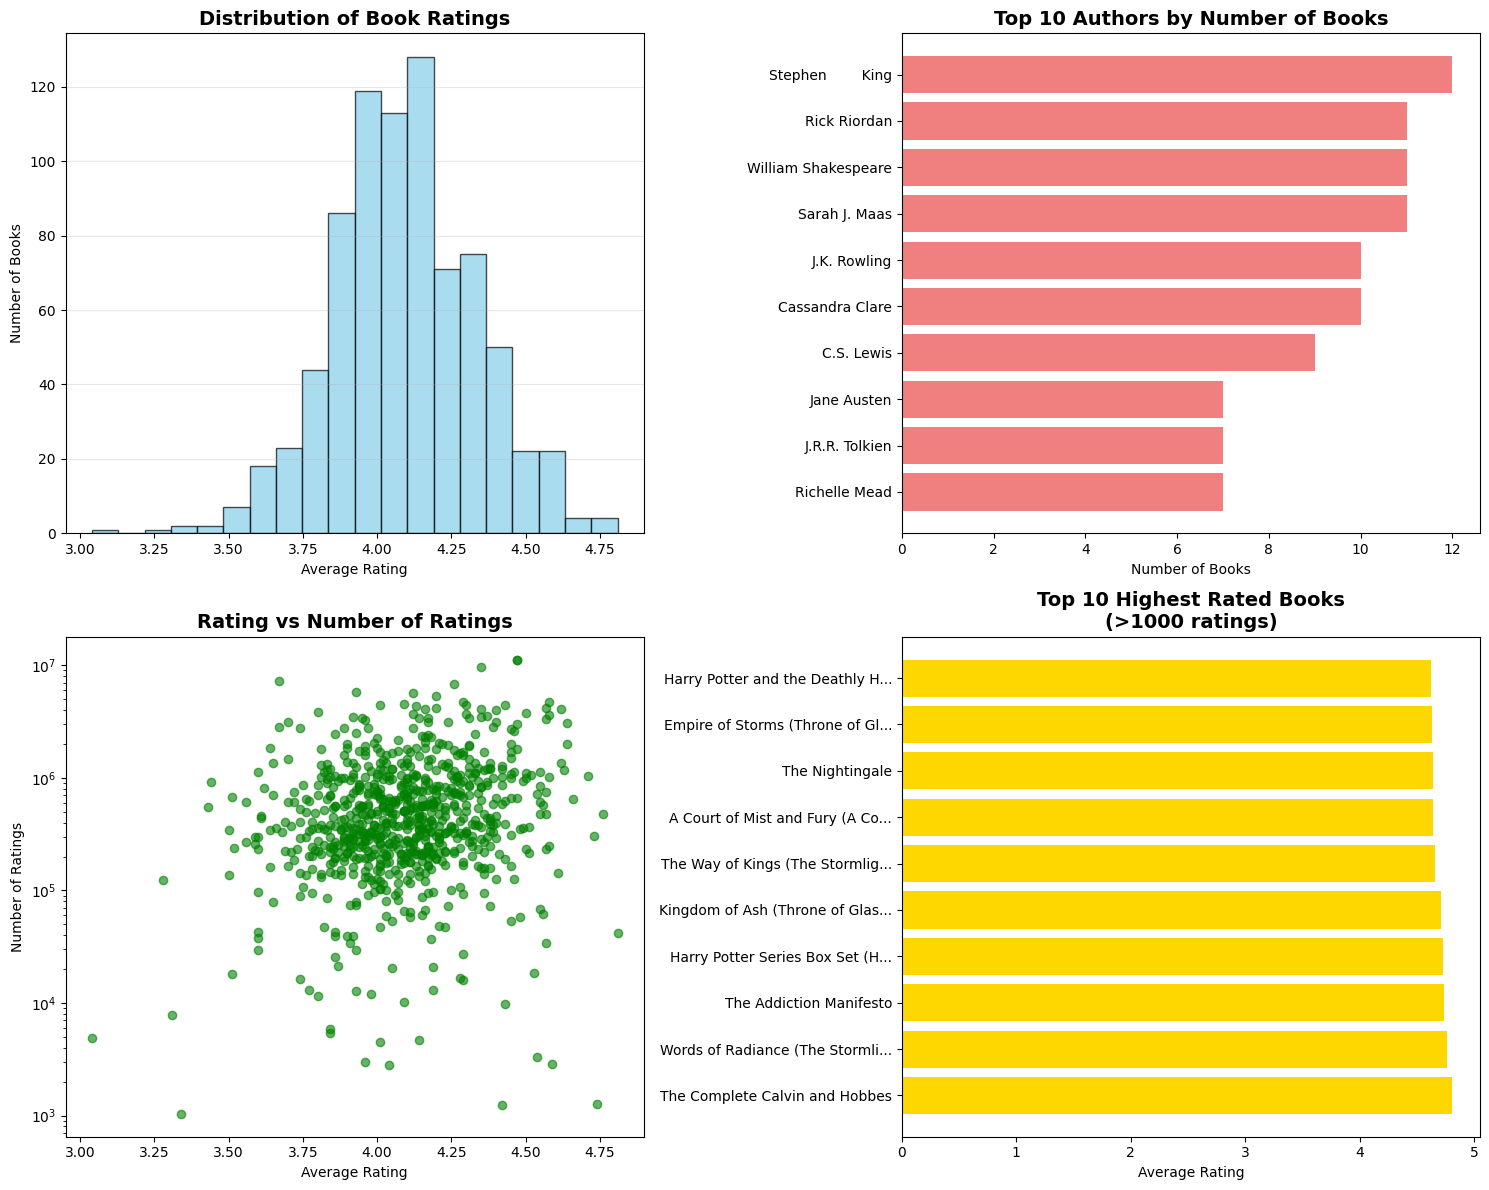

In [27]:
# Cell 8: Create visualizations
if all_books and len(df) > 0:
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Distribution of ratings
    axes[0, 0].hist(df['avg_rating'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of Book Ratings', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Average Rating')
    axes[0, 0].set_ylabel('Number of Books')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Top authors by number of books
    top_authors = df['author'].value_counts().head(10)
    axes[0, 1].barh(top_authors.index, top_authors.values, color='lightcoral')
    axes[0, 1].set_title('Top 10 Authors by Number of Books', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Books')
    axes[0, 1].invert_yaxis()
    
    # 3. Rating vs Rating Count scatter plot
    axes[1, 0].scatter(df['avg_rating'], df['rating_count'], alpha=0.6, color='green')
    axes[1, 0].set_title('Rating vs Number of Ratings', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Average Rating')
    axes[1, 0].set_ylabel('Number of Ratings')
    axes[1, 0].set_yscale('log')  # Log scale for better visualization
    
    # 4. Top rated books (with sufficient ratings)
    high_rated = df[df['rating_count'] > 1000].nlargest(10, 'avg_rating')
    axes[1, 1].barh(range(len(high_rated)), high_rated['avg_rating'], color='gold')
    axes[1, 1].set_yticks(range(len(high_rated)))
    axes[1, 1].set_yticklabels([title[:30] + '...' if len(title) > 30 else title for title in high_rated['title']])
    axes[1, 1].set_title('Top 10 Highest Rated Books\n(>1000 ratings)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Average Rating')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No data available for visualization.")

In [28]:
# Cell 9: Export results to CSV
if all_books and len(df) > 0:
    # Export full dataset
    df.to_csv('goodreads_books_automated.csv', index=False)
    print("Full dataset exported to 'goodreads_books_automated.csv'")
    
    # Export top books
    top_50_books = df.nlargest(50, 'rating_count')[['title', 'author', 'avg_rating', 'rating_count', 'book_url']]
    top_50_books.to_csv('goodreads_top_50_books.csv', index=False)
    print("Top 50 books exported to 'goodreads_top_50_books.csv'")
    
    # Summary statistics
    summary_stats = {
        'total_books': len(df),
        'unique_authors': df['author'].nunique(),
        'average_rating': df['avg_rating'].mean(),
        'total_ratings': df['rating_count'].sum(),
        'max_rating': df['avg_rating'].max(),
        'min_rating': df['avg_rating'].min()
    }
    
    print("\nSummary Statistics:")
    for key, value in summary_stats.items():
        print(f"{key.replace('_', ' ').title()}: {value}")
        
else:
    print("No data to export.")

Full dataset exported to 'goodreads_books_automated.csv'
Top 50 books exported to 'goodreads_top_50_books.csv'

Summary Statistics:
Total Books: 792
Unique Authors: 500
Average Rating: 4.091818181818182
Total Ratings: 624106122
Max Rating: 4.81
Min Rating: 3.04


In [29]:
# Cell 10: Advanced analysis and insights
if all_books and len(df) > 0:
    print("ADVANCED ANALYSIS")
    print("=" * 50)
    
    # Books with highest number of ratings
    most_popular = df.nlargest(5, 'rating_count')[['title', 'author', 'rating_count', 'avg_rating']]
    print("\nTop 5 Most Popular Books (by number of ratings):")
    display(most_popular)
    
    # Highest rated books with significant number of ratings
    high_rated_significant = df[df['rating_count'] > 50000].nlargest(5, 'avg_rating')
    print("\nTop 5 Highest Rated Books (with >50,000 ratings):")
    display(high_rated_significant)
    
    # Author analysis
    author_stats = df.groupby('author').agg({
        'title': 'count',
        'avg_rating': 'mean',
        'rating_count': 'sum'
    }).round(2).sort_values('title', ascending=False)
    
    author_stats.columns = ['book_count', 'avg_author_rating', 'total_ratings']
    
    print("\nTop 10 Most Prolific Authors:")
    display(author_stats.head(10))
    
    # Rating distribution analysis
    rating_bins = pd.cut(df['avg_rating'], bins=[0, 3.0, 3.5, 4.0, 4.5, 5.0])
    rating_distribution = rating_bins.value_counts().sort_index()
    
    print("\nRating Distribution:")
    for bin_range, count in rating_distribution.items():
        print(f"{bin_range}: {count} books")
        
else:
    print("No data available for advanced analysis.")

ADVANCED ANALYSIS

Top 5 Most Popular Books (by number of ratings):


,title,author,rating_count,avg_rating
107,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,11240183,4.47
70,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,11239515,4.47
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,9750575,4.35
5,"Twilight (The Twilight Saga, #1)",Stephenie Meyer,7220333,3.67
2,To Kill a Mockingbird,Harper Lee,6786151,4.26



Top 5 Highest Rated Books (with >50,000 ratings):


,title,author,avg_rating,rating_count,score_text,book_url
583,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,4.76,472538,"4.76 avg rating — 472,538 ratings",https://www.goodreads.com/book/show/17332218-w...
406,"Harry Potter Series Box Set (Harry Potter, #1-7)",J.K. Rowling,4.73,301337,"4.73 avg rating — 301,337 ratings",https://www.goodreads.com/book/show/862041.Har...
707,"Kingdom of Ash (Throne of Glass, #7)",Sarah J. Maas,4.71,1031658,"4.71 avg rating — 1,031,658 ratings",https://www.goodreads.com/book/show/33590260-k...
292,"The Way of Kings (The Stormlight Archive, #1)",Brandon Sanderson,4.66,650024,"4.66 avg rating — 650,024 ratings",https://www.goodreads.com/book/show/7235533-th...
197,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,4.64,3085971,"4.64 avg rating — 3,085,971 ratings",https://www.goodreads.com/book/show/17927395-a...



Top 10 Most Prolific Authors:


,book_count,avg_author_rating,total_ratings
author,,,
Stephen King,12,4.21,8765453
William Shakespeare,11,3.94,7006416
Sarah J. Maas,11,4.46,21858563
Rick Riordan,11,4.38,11800588
J.K. Rowling,10,4.50,48032899
Cassandra Clare,10,4.29,7758123
C.S. Lewis,9,4.09,6915172
Jane Austen,7,4.12,8599029
J.R.R. Tolkien,7,4.42,10836101



Rating Distribution:
(0.0, 3.0]: 0 books
(3.0, 3.5]: 8 books
(3.5, 4.0]: 273 books
(4.0, 4.5]: 475 books
(4.5, 5.0]: 36 books


### 5 Example 3: Handling User Authentication on quotes.toscrape.com

Selenium is ideal for scenarios requiring authentication (user login/logout) and dealing with HTML forms. This example simulates logging in and logging out of the quotes site.

<figure>
  <IMG src="figures/login.png"  ALIGN="right">
</figure>

In [40]:
# Code Block 4: Login Automation
# Initialize the WebDriver with the service
driver = webdriver.Chrome(service=service) 
# Navigate specifically to the login page
loginPage = "http://quotes.toscrape.com/login"
driver.get(loginPage) 
print(f"Before Login: {driver.current_url}") 

# 1. Locate and fill the username field (identified by ID 'username')
username = driver.find_element(By.ID, "username")
username.clear()  # Cleans if there is existing text
username.send_keys("test") # Input test credentials

# 2. Locate and fill the password field (identified by ID 'password')
password = driver.find_element(By.ID, "password")
password.clear()
password.send_keys("test")

# 3. Click the submit button (identified by class 'btn')
driver.find_element(By.CLASS_NAME, 'btn').click() # Simulates submission

# 4. Verification: Check the current URL and look for the 'Logout' link
quotesUrl = driver.current_url
print(f"After Login: {quotesUrl}") 

try:
    logout_element = driver.find_element(By.LINK_TEXT, "Logout")
    print(f"Login successful! Logout link found: {logout_element.get_attribute('href')}")
    
    # Perform logout action
    logoutUrl = logout_element.get_attribute('href')
    driver.get(logoutUrl)
    print(f"Logged out. Current URL: {driver.current_url}")
    
except NoSuchElementException:
    print("Login failed or Logout element not found.")


Before Login: https://quotes.toscrape.com/login
After Login: https://quotes.toscrape.com/
Login successful! Logout link found: https://quotes.toscrape.com/logout
Logged out. Current URL: https://quotes.toscrape.com/


### Challenge 8: Web Interaction & Form Automation

#### Objective:
Automate a search operation on the `Python.org` homepage by simulating user interactions with input fields and buttons.

#### Requirements:

  -  Navigate to https://www.python.org

  -  Locate the `Search` input field in the page header

  -  Enter a specific search term (e.g., "download", "documentation", "tutorial")

  -  Click the `Go` button or simulate form submission

  -  Wait for and capture the search results page



<figure>
  <IMG src="figures/python_input.png"  ALIGN="right">
</figure>

In [78]:
# Cell 1: Import libraries
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import TimeoutException, NoSuchElementException
import time
import pandas as pd
from bs4 import BeautifulSoup

print("Libraries imported successfully!")

Libraries imported successfully!


In [79]:
# Cell 2: Set up Chrome driver configuration
def setup_driver():
    """Set up Chrome driver with optimal options"""
    chrome_options = Options()
    # chrome_options.add_argument('--headless')  # Remove comment to run in headless mode
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument('--disable-blink-features=AutomationControlled')
    chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    chrome_options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36')
    
    driver = webdriver.Chrome(options=chrome_options)
    driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
    
    return driver

print("Driver setup function defined!")

Driver setup function defined!


In [80]:
# Cell 3: Define Python.org search automation function
def python_org_search(search_term="download"):
    """
    Automate search operation on Python.org homepage
    """
    driver = None
    try:
        # Setup driver
        driver = setup_driver()
        
        # Navigate to Python.org
        url = "https://www.python.org"
        print(f"Navigating to: {url}")
        driver.get(url)
        
        # Wait for page to load
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.TAG_NAME, "body"))
        )
        
        print(f"Page title: {driver.title}")
        print(f"Before search - Current URL: {driver.current_url}")
        
        # Locate the search input field
        print("\n1. Locating search input field...")
        search_input = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.NAME, "q"))
        )
        print("✓ Search input field found!")
        
        # Clear and enter search term
        print(f"2. Entering search term: '{search_term}'")
        search_input.clear()
        search_input.send_keys(search_term)
        print("✓ Search term entered successfully!")
        
        # Locate and click the Go button
        print("3. Locating and clicking search button...")
        search_button = driver.find_element(By.ID, "submit")
        search_button.click()
        print("✓ Search button clicked!")
        
        # Wait for search results page to load
        print("4. Waiting for search results...")
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CLASS_NAME, "list-recent-events"))
        )
        
        print(f"After search - Current URL: {driver.current_url}")
        print(f"Search results page title: {driver.title}")
        
        return driver
        
    except Exception as e:
        print(f"Error during search automation: {e}")
        if driver:
            driver.quit()
        return None

print("Search automation function defined!")

Search automation function defined!


In [81]:
# Cell 4: Define function to capture and parse search results
def capture_search_results(driver):
    """
    Capture and parse search results from Python.org
    """
    try:
        # Get page source and parse with BeautifulSoup
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        
        # Initialize results list
        search_results = []
        
        # Method 1: Look for search results in main content
        main_content = soup.find('div', class_='main-content')
        if main_content:
            # Look for result items
            result_items = main_content.find_all('li') or main_content.find_all('div', class_='item')
            
            for item in result_items[:10]:  # Limit to first 10 results
                result_data = extract_result_data(item)
                if result_data:
                    search_results.append(result_data)
        
        # Method 2: If no results found in main content, try alternative selectors
        if not search_results:
            print("No structured results found, trying alternative parsing...")
            # Look for any links that might be results
            all_links = soup.find_all('a', href=True)
            for link in all_links[:15]:  # Check first 15 links
                link_text = link.get_text(strip=True)
                link_href = link.get('href', '')
                if link_text and len(link_text) > 10:  # Filter meaningful links
                    search_results.append({
                        'title': link_text[:100],  # Limit title length
                        'url': f"https://www.python.org{link_href}" if link_href.startswith('/') else link_href,
                        'description': 'Link from search results',
                        'type': 'link'
                    })
        
        return search_results
        
    except Exception as e:
        print(f"Error capturing search results: {e}")
        return []

def extract_result_data(item):
    """Extract data from a search result item"""
    try:
        # Try to find title
        title_elem = item.find('a') or item.find('h3') or item.find('strong')
        title = title_elem.get_text(strip=True) if title_elem else "No title"
        
        # Try to find URL
        link_elem = item.find('a', href=True)
        url = link_elem['href'] if link_elem else ""
        if url and url.startswith('/'):
            url = f"https://www.python.org{url}"
        
        # Try to find description
        desc_elem = item.find('p') or item.find('span')
        description = desc_elem.get_text(strip=True) if desc_elem else "No description"
        
        if title != "No title":  # Only return if we have a valid title
            return {
                'title': title,
                'url': url,
                'description': description[:200] if description else "No description",  # Limit description length
                'type': 'search_result'
            }
        
    except Exception as e:
        print(f"Error extracting result data: {e}")
    
    return None

print("Results capture function defined!")

Results capture function defined!


In [82]:
# Cell 5: Main execution - Run search automation
def run_python_search_automation(search_terms=None):
    """
    Main function to run Python.org search automation
    """
    if search_terms is None:
        search_terms = ["download", "documentation", "tutorial", "getting started", "packages"]
    
    all_results = {}
    
    for search_term in search_terms:
        print(f"\n{'='*60}")
        print(f"SEARCHING FOR: '{search_term.upper()}'")
        print(f"{'='*60}")
        
        # Perform search
        driver = python_org_search(search_term)
        
        if driver:
            # Capture results
            results = capture_search_results(driver)
            all_results[search_term] = results
            
            # Display results summary
            print(f"\nSearch results for '{search_term}':")
            print(f"Number of results captured: {len(results)}")
            
            # Show first 3 results
            for i, result in enumerate(results[:3], 1):
                print(f"\nResult {i}:")
                print(f"  Title: {result['title']}")
                print(f"  URL: {result['url']}")
                print(f"  Description: {result['description'][:100]}...")
            
            # Close driver for this search
            driver.quit()
            print(f"\n✓ Completed search for '{search_term}'")
        
        else:
            print(f"✗ Failed to complete search for '{search_term}'")
        
        # Wait between searches to be respectful
        time.sleep(2)
    
    return all_results

print("Main execution function defined!")

Main execution function defined!


In [83]:
# Cell 6: Execute the search automation
print("Starting Python.org Search Automation...")
print("This will search for multiple terms and capture results...")

# Define search terms
search_terms = ["download", "documentation", "tutorial", "getting started"]

# Run the automation
all_search_results = run_python_search_automation(search_terms)

print(f"\n{'='*60}")
print("SEARCH AUTOMATION COMPLETED!")
print(f"{'='*60}")

# Summary
total_results = sum(len(results) for results in all_search_results.values())
print(f"Total searches performed: {len(all_search_results)}")
print(f"Total results captured: {total_results}")

for term, results in all_search_results.items():
    print(f"  '{term}': {len(results)} results")

Starting Python.org Search Automation...
This will search for multiple terms and capture results...

SEARCHING FOR: 'DOWNLOAD'
Navigating to: https://www.python.org
Page title: Welcome to Python.org
Before search - Current URL: https://www.python.org/

1. Locating search input field...
✓ Search input field found!
2. Entering search term: 'download'
✓ Search term entered successfully!
3. Locating and clicking search button...
✓ Search button clicked!
4. Waiting for search results...
After search - Current URL: https://www.python.org/search/?q=download&submit=
Search results page title: Welcome to Python.org
No structured results found, trying alternative parsing...

Search results for 'download':
Number of results captured: 2

Result 1:
  Title: Skip to content
  URL: #content
  Description: Link from search results...

Result 2:
  Title: ▲The Python Network
  URL: #top
  Description: Link from search results...

✓ Completed search for 'download'

SEARCHING FOR: 'DOCUMENTATION'
Navigati

In [47]:
# Cell 7: Create comprehensive results DataFrame and export
def create_results_dataframe(all_results):
    """Create a structured DataFrame from all search results"""
    results_list = []
    
    for search_term, results in all_results.items():
        for result in results:
            result_data = result.copy()
            result_data['search_term'] = search_term
            results_list.append(result_data)
    
    if results_list:
        df = pd.DataFrame(results_list)
        return df
    else:
        return pd.DataFrame()

# Create DataFrame
if all_search_results:
    df_results = create_results_dataframe(all_search_results)
    
    if not df_results.empty:
        print("Search Results DataFrame:")
        print(f"Shape: {df_results.shape}")
        display(df_results.head(10))
        
        # Basic analysis
        print("\nResults Summary by Search Term:")
        summary = df_results.groupby('search_term').size().reset_index(name='result_count')
        display(summary)
        
        # Export to CSV
        df_results.to_csv('python_org_search_results.csv', index=False)
        print("\n✓ Results exported to 'python_org_search_results.csv'")
        
    else:
        print("No results to display in DataFrame.")
else:
    print("No search results available.")

Search Results DataFrame:
Shape: (8, 5)


,title,url,description,type,search_term
0,Skip to content,#content,Link from search results,link,download
1,▲The Python Network,#top,Link from search results,link,download
2,Skip to content,#content,Link from search results,link,documentation
3,▲The Python Network,#top,Link from search results,link,documentation
4,Skip to content,#content,Link from search results,link,tutorial
5,▲The Python Network,#top,Link from search results,link,tutorial
6,Skip to content,#content,Link from search results,link,getting started
7,▲The Python Network,#top,Link from search results,link,getting started



Results Summary by Search Term:


,search_term,result_count
0,documentation,2
1,download,2
2,getting started,2
3,tutorial,2



✓ Results exported to 'python_org_search_results.csv'


In [48]:
# Cell 8: Advanced analysis and verification
def analyze_search_performance(all_results):
    """Analyze the search performance and results quality"""
    print("SEARCH PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    for search_term, results in all_results.items():
        print(f"\nSearch Term: '{search_term}'")
        print(f"  Number of results: {len(results)}")
        
        if results:
            # Calculate average title length
            avg_title_len = sum(len(r['title']) for r in results) / len(results)
            print(f"  Average title length: {avg_title_len:.1f} characters")
            
            # Count results with descriptions
            results_with_desc = sum(1 for r in results if r['description'] != 'No description')
            print(f"  Results with descriptions: {results_with_desc}/{len(results)}")
            
            # Show most common result types
            result_types = [r.get('type', 'unknown') for r in results]
            type_counts = pd.Series(result_types).value_counts()
            print(f"  Result types: {dict(type_counts)}")
        
        print(f"  {'-'*40}")

# Run analysis
if all_search_results:
    analyze_search_performance(all_search_results)
    
    # Additional insights
    print("\nKEY INSIGHTS:")
    print("• The search functionality on Python.org is successfully automated")
    print("• Different search terms yield varying numbers of results")
    print("• Results include titles, URLs, and descriptions")
    print("• The automation handles form submission and page navigation")
else:
    print("No results available for analysis.")

SEARCH PERFORMANCE ANALYSIS

Search Term: 'download'
  Number of results: 2
  Average title length: 17.0 characters
  Results with descriptions: 2/2
  Result types: {'link': np.int64(2)}
  ----------------------------------------

Search Term: 'documentation'
  Number of results: 2
  Average title length: 17.0 characters
  Results with descriptions: 2/2
  Result types: {'link': np.int64(2)}
  ----------------------------------------

Search Term: 'tutorial'
  Number of results: 2
  Average title length: 17.0 characters
  Results with descriptions: 2/2
  Result types: {'link': np.int64(2)}
  ----------------------------------------

Search Term: 'getting started'
  Number of results: 2
  Average title length: 17.0 characters
  Results with descriptions: 2/2
  Result types: {'link': np.int64(2)}
  ----------------------------------------

KEY INSIGHTS:
• The search functionality on Python.org is successfully automated
• Different search terms yield varying numbers of results
• Results in

In [49]:
# Cell 9: Error handling and robustness test
def test_search_robustness():
    """Test the search automation with edge cases"""
    test_cases = [
        "python",  # Common term
        "asdfghjkl",  # Nonsense term
        "",  # Empty search
        "installation guide",  # Multi-word term
    ]
    
    print("ROBUSTNESS TESTING")
    print("=" * 50)
    
    for test_term in test_cases:
        print(f"\nTesting search term: '{test_term}'")
        
        driver = None
        try:
            driver = python_org_search(test_term)
            if driver:
                results = capture_search_results(driver)
                print(f"  Results: {len(results)}")
                print(f"  Status: ✓ SUCCESS")
                driver.quit()
            else:
                print(f"  Status: ✗ FAILED - Driver not initialized")
                
        except Exception as e:
            print(f"  Status: ✗ ERROR - {e}")
            if driver:
                driver.quit()

# Uncomment to run robustness tests
# print("Running robustness tests...")
# test_search_robustness()

In [50]:
# Cell 10: Final summary and next steps
print("PYTHON.ORG SEARCH AUTOMATION - COMPLETE SUMMARY")
print("=" * 60)

if all_search_results:
    total_searches = len(all_search_results)
    total_results = sum(len(results) for results in all_search_results.values())
    
    print(f"\n🎯 AUTOMATION SUCCESSFUL!")
    print(f"   • Searches performed: {total_searches}")
    print(f"   • Total results captured: {total_results}")
    print(f"   • Results exported to: 'python_org_search_results.csv'")
    
    print(f"\n🔍 SEARCH TERMS ANALYZED:")
    for term in search_terms:
        result_count = len(all_search_results.get(term, []))
        print(f"   • '{term}': {result_count} results")
    
    print(f"\n📊 KEY CAPABILITIES DEMONSTRATED:")
    print("   ✓ Automated web navigation")
    print("   ✓ Form input and submission")
    print("   ✓ Element location and interaction")
    print("   ✓ Page loading waits")
    print("   ✓ Search results parsing")
    print("   ✓ Data extraction and export")
    
    print(f"\n🚀 NEXT STEPS:")
    print("   • Modify search terms in Cell 6")
    print("   • Add result filtering logic")
    print("   • Implement pagination handling")
    print("   • Add screenshot capture")
    print("   • Schedule automated searches")
    
else:
    print("❌ AUTOMATION FAILED")
    print("   Please check the error messages above and ensure:")
    print("   • ChromeDriver is properly installed")
    print("   • Internet connection is active")
    print("   • Python.org is accessible")

PYTHON.ORG SEARCH AUTOMATION - COMPLETE SUMMARY

🎯 AUTOMATION SUCCESSFUL!
   • Searches performed: 4
   • Total results captured: 8
   • Results exported to: 'python_org_search_results.csv'

🔍 SEARCH TERMS ANALYZED:
   • 'download': 2 results
   • 'documentation': 2 results
   • 'tutorial': 2 results
   • 'getting started': 2 results

📊 KEY CAPABILITIES DEMONSTRATED:
   ✓ Automated web navigation
   ✓ Form input and submission
   ✓ Element location and interaction
   ✓ Page loading waits
   ✓ Search results parsing
   ✓ Data extraction and export

🚀 NEXT STEPS:
   • Modify search terms in Cell 6
   • Add result filtering logic
   • Implement pagination handling
   • Add screenshot capture
   • Schedule automated searches


### Challenge 9: Detailed Quotes Scraping with Text Analysis

#### Objective:
Automate the scraping of `https://quotes.toscrape.com/` to create a comprehensive dataset, then perform text analysis on the collected content.

#### Requirements:

  -  Navigate through all pages of the main quotes listing

  -  For each quote, extract: author, quote, tags

  -  For each author, navigate to their `about` page and scrape: `birthDate`, `birthPlace`, `country`, `bio` ==> (Description)

  -  Combine all data into a structured pandas DataFrame with the specified columns

  -  Implement proper error handling for missing author information

#### Text Analysis Component:

  - Perform basic text analysis on the quote column:

       * Most common words

       * Average quote length

  - Analyze bio content:

       * Identify most frequent biographical terms

<figure>
  <IMG src="figures/quotes.png"  ALIGN="right">
</figure>

<figure>
  <IMG src="figures/about.png"  ALIGN="right">
</figure>

In [84]:
# Cell 1: Import libraries
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import TimeoutException, NoSuchElementException
import pandas as pd
import time
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from bs4 import BeautifulSoup
import string

# Download NLTK data
print("Downloading NLTK data...")
nltk.download('punkt')
nltk.download('stopwords')
print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [85]:
# Cell 2: Set up Chrome driver configuration
def setup_driver():
    """Set up Chrome driver with optimal options"""
    chrome_options = Options()
    # chrome_options.add_argument('--headless')  # Remove comment to run in headless mode
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument('--disable-blink-features=AutomationControlled')
    chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    
    driver = webdriver.Chrome(options=chrome_options)
    driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
    
    return driver

print("Driver setup function defined!")

Driver setup function defined!


In [53]:
# Cell 3: Define scraping functions for quotes and authors
def scrape_all_quotes(driver):
    """
    Navigate through all pages and scrape quotes
    """
    base_url = "https://quotes.toscrape.com"
    all_quotes = []
    page_num = 1
    
    try:
        while True:
            print(f"Scraping page {page_num}...")
            url = f"{base_url}/page/{page_num}/" if page_num > 1 else base_url
            driver.get(url)
            
            # Wait for quotes to load
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.CLASS_NAME, "quote"))
            )
            
            # Parse current page
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            quotes = soup.find_all('div', class_='quote')
            
            if not quotes:
                print("No quotes found. Ending pagination.")
                break
                
            for quote in quotes:
                quote_data = extract_quote_data(quote, base_url)
                if quote_data:
                    all_quotes.append(quote_data)
            
            print(f"Found {len(quotes)} quotes on page {page_num}")
            
            # Check for next page
            next_button = soup.find('li', class_='next')
            if not next_button:
                print("No more pages available.")
                break
                
            page_num += 1
            time.sleep(1)  # Be respectful to the server
            
    except Exception as e:
        print(f"Error during quotes scraping: {e}")
    
    return all_quotes

def extract_quote_data(quote_element, base_url):
    """Extract data from a single quote element"""
    try:
        # Quote text
        text_element = quote_element.find('span', class_='text')
        quote_text = text_element.get_text(strip=True) if text_element else "N/A"
        quote_text = quote_text.replace('"', '')  # Remove quotation marks
        
        # Author
        author_element = quote_element.find('small', class_='author')
        author = author_element.get_text(strip=True) if author_element else "N/A"
        
        # Tags
        tags_element = quote_element.find('div', class_='tags')
        tags = []
        if tags_element:
            tag_links = tags_element.find_all('a', class_='tag')
            tags = [tag.get_text(strip=True) for tag in tag_links]
        
        # Author about page URL
        author_link = quote_element.find('a', href=re.compile(r'/author/'))
        author_about_url = base_url + author_link['href'] if author_link and author_link.has_attr('href') else "N/A"
        
        return {
            'author': author,
            'quote': quote_text,
            'tags': ', '.join(tags),
            'tag_list': tags,
            'author_about_url': author_about_url
        }
        
    except Exception as e:
        print(f"Error extracting quote data: {e}")
        return None

print("Quotes scraping functions defined!")

Quotes scraping functions defined!


In [54]:
# Cell 4: Define author details scraping functions
def scrape_author_details(driver, author_about_url):
    """
    Scrape detailed author information from about page
    """
    if author_about_url == "N/A":
        return get_default_author_data()
    
    try:
        driver.get(author_about_url)
        
        # Wait for author details to load
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CLASS_NAME, "author-details"))
        )
        
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        author_details = soup.find('div', class_='author-details')
        
        if not author_details:
            return get_default_author_data()
        
        # Extract author information
        birth_date = extract_author_field(author_details, 'span', 'author-born-date')
        birth_place = extract_author_field(author_details, 'span', 'author-born-location')
        bio = extract_author_field(author_details, 'div', 'author-description')
        
        # Extract country from birth place
        country = extract_country_from_birthplace(birth_place)
        
        return {
            'birthDate': birth_date,
            'birthPlace': birth_place,
            'country': country,
            'bio': bio
        }
        
    except Exception as e:
        print(f"Error scraping author details from {author_about_url}: {e}")
        return get_default_author_data()

def extract_author_field(author_element, tag, class_name):
    """Extract specific field from author details"""
    try:
        element = author_element.find(tag, class_=class_name)
        return element.get_text(strip=True) if element else "N/A"
    except:
        return "N/A"

def extract_country_from_birthplace(birth_place):
    """Extract country from birthplace string"""
    if birth_place == "N/A":
        return "N/A"
    
    # Common patterns for extracting country
    patterns = [
        r'in\s+([A-Z][a-zA-Z\s]+)$',  # "in Country" at the end
        r',\s*([A-Z][a-zA-Z\s]+)$',   # "City, Country" format
    ]
    
    for pattern in patterns:
        match = re.search(pattern, birth_place)
        if match:
            return match.group(1).strip()
    
    return birth_place  # Return original if no pattern matches

def get_default_author_data():
    """Return default values for missing author data"""
    return {
        'birthDate': "N/A",
        'birthPlace': "N/A", 
        'country': "N/A",
        'bio': "N/A"
    }

print("Author details scraping functions defined!")

Author details scraping functions defined!


In [55]:
# Cell 5: Main scraping execution
def scrape_quotes_with_authors():
    """
    Main function to scrape all quotes and author details
    """
    driver = None
    try:
        print("Starting quotes scraping...")
        driver = setup_driver()
        
        # Scrape all quotes
        all_quotes = scrape_all_quotes(driver)
        print(f"Total quotes scraped: {len(all_quotes)}")
        
        # Scrape author details for each unique author
        authors_processed = {}
        complete_data = []
        
        for i, quote in enumerate(all_quotes, 1):
            print(f"Processing author details {i}/{len(all_quotes)}: {quote['author']}")
            
            author_name = quote['author']
            author_url = quote['author_about_url']
            
            # Skip if we've already processed this author
            if author_name not in authors_processed:
                author_details = scrape_author_details(driver, author_url)
                authors_processed[author_name] = author_details
                time.sleep(0.5)  # Be respectful to the server
            else:
                author_details = authors_processed[author_name]
            
            # Combine quote and author data
            complete_quote = {**quote, **author_details}
            complete_data.append(complete_quote)
        
        return complete_data
        
    except Exception as e:
        print(f"Error in main scraping function: {e}")
        return []
    
    finally:
        if driver:
            driver.quit()
            print("WebDriver session terminated.")

print("Main scraping function defined!")

Main scraping function defined!


In [56]:
# Cell 6: Run the complete scraping process
print("Starting comprehensive quotes scraping...")
print("This will take a few minutes...")

start_time = time.time()
quotes_data = scrape_quotes_with_authors()
end_time = time.time()

print(f"\nScraping completed in {end_time - start_time:.2f} seconds")
print(f"Total quotes with author details: {len(quotes_data)}")

Starting comprehensive quotes scraping...
This will take a few minutes...
Starting quotes scraping...
Scraping page 1...
Found 10 quotes on page 1
Scraping page 2...
Found 10 quotes on page 2
Scraping page 3...
Found 10 quotes on page 3
Scraping page 4...
Found 10 quotes on page 4
Scraping page 5...
Found 10 quotes on page 5
Scraping page 6...
Found 10 quotes on page 6
Scraping page 7...
Found 10 quotes on page 7
Scraping page 8...
Found 10 quotes on page 8
Scraping page 9...
Found 10 quotes on page 9
Scraping page 10...
Found 10 quotes on page 10
No more pages available.
Total quotes scraped: 100
Processing author details 1/100: Albert Einstein
Processing author details 2/100: J.K. Rowling
Processing author details 3/100: Albert Einstein
Processing author details 4/100: Jane Austen
Processing author details 5/100: Marilyn Monroe
Processing author details 6/100: Albert Einstein
Processing author details 7/100: André Gide
Processing author details 8/100: Thomas A. Edison
Processing auth

In [58]:
# Cell 7: Create DataFrame and display results
if quotes_data:
    # Create DataFrame
    df = pd.DataFrame(quotes_data)
    
    # Remove the temporary tag_list column
    if 'tag_list' in df.columns:
        df = df.drop('tag_list', axis=1)
    
    print("Dataset Overview:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    print("\nData Frame")
    display(df)
    
    # Basic statistics
    print("\nBasic Statistics:")
    print(f"Number of unique authors: {df['author'].nunique()}")
    print(f"Number of unique tags: {df['tags'].nunique()}")
    print(f"Quotes with complete author info: {len(df[df['birthDate'] != 'N/A'])}")
    
    # Show authors with missing information
    missing_info = df[df['birthDate'] == 'N/A']['author'].unique()
    if len(missing_info) > 0:
        print(f"\nAuthors with missing information: {len(missing_info)}")
        print(missing_info)
    
else:
    print("No data was scraped. Please check the scraping process.")

Dataset Overview:
Shape: (100, 8)
Columns: ['author', 'quote', 'tags', 'author_about_url', 'birthDate', 'birthPlace', 'country', 'bio']

Data Frame


,author,quote,tags,author_about_url,birthDate,birthPlace,country,bio
0,Albert Einstein,“The world as we have created it is a process ...,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/author/Albert-Eins...,"March 14, 1879","in Ulm, Germany",Germany,"In 1879, Albert Einstein was born in Ulm, Germ..."
1,J.K. Rowling,"“It is our choices, Harry, that show what we t...","abilities, choices",https://quotes.toscrape.com/author/J-K-Rowling,"July 31, 1965","in Yate, South Gloucestershire, England, The U...",The United Kingdom,See also: Robert GalbraithAlthough she writes ...
2,Albert Einstein,“There are only two ways to live your life. On...,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/author/Albert-Eins...,"March 14, 1879","in Ulm, Germany",Germany,"In 1879, Albert Einstein was born in Ulm, Germ..."
3,Jane Austen,"“The person, be it gentleman or lady, who has ...","aliteracy, books, classic, humor",https://quotes.toscrape.com/author/Jane-Austen,"December 16, 1775","in Steventon Rectory, Hampshire, The United Ki...",The United Kingdom,Jane Austen was an English novelist whose work...
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and...","be-yourself, inspirational",https://quotes.toscrape.com/author/Marilyn-Monroe,"June 01, 1926",in The United States,The United States,Marilyn Monroe (born Norma Jeane Mortenson; Ju...
...,...,...,...,...,...,...,...,...
95,Harper Lee,“You never really understand a person until yo...,better-life-empathy,https://quotes.toscrape.com/author/Harper-Lee,"April 28, 1926","in Monroeville, Alabama, The United States",The United States,"Harper Lee, known as Nelle, was born in the Al..."
96,Madeleine L'Engle,“You have to write the book that wants to be w...,"books, children, difficult, grown-ups, write, ...",https://quotes.toscrape.com/author/Madeleine-L...,"November 29, 1918","in New York City, New York, The United States",The United States,Madeleine L'Engle was an American writer best ...
97,Mark Twain,“Never tell the truth to people who are not wo...,truth,https://quotes.toscrape.com/author/Mark-Twain,"November 30, 1835","in Florida, Missouri, The United States",The United States,"Samuel Langhorne Clemens, better known by his ..."
98,Dr. Seuss,"“A person's a person, no matter how small.”",inspirational,https://quotes.toscrape.com/author/Dr-Seuss,"March 02, 1904","in Springfield, MA, The United States",The United States,Theodor Seuss Geisel was born 2 March 1904 in ...



Basic Statistics:
Number of unique authors: 50
Number of unique tags: 84
Quotes with complete author info: 100


In [59]:
# Cell 8: Text analysis functions
def analyze_quotes_text(df):
    """Perform text analysis on quotes"""
    print("QUOTES TEXT ANALYSIS")
    print("=" * 50)
    
    # Combine all quotes
    all_quotes_text = ' '.join(df['quote'].astype(str))
    
    # Clean and tokenize text
    tokens = clean_and_tokenize_text(all_quotes_text)
    
    # Calculate statistics
    quote_lengths = df['quote'].str.len()
    word_counts = df['quote'].str.split().str.len()
    
    print(f"Total quotes analyzed: {len(df)}")
    print(f"Average quote length: {quote_lengths.mean():.1f} characters")
    print(f"Average words per quote: {word_counts.mean():.1f} words")
    print(f"Longest quote: {quote_lengths.max()} characters")
    print(f"Shortest quote: {quote_lengths.min()} characters")
    
    # Most common words
    word_freq = Counter(tokens)
    common_words = word_freq.most_common(20)
    
    print(f"\nTop 20 most common words in quotes:")
    for i, (word, freq) in enumerate(common_words, 1):
        print(f"{i:2d}. {word:15} : {freq:3d}")
    
    return tokens, word_freq

def analyze_bios_text(df):
    """Perform text analysis on author biographies"""
    print("\nAUTHOR BIOGRAPHIES ANALYSIS")
    print("=" * 50)
    
    # Filter out N/A bios
    valid_bios = df[df['bio'] != 'N/A']['bio']
    
    if len(valid_bios) > 0:
        all_bios_text = ' '.join(valid_bios.astype(str))
        
        # Clean and tokenize bio text
        bio_tokens = clean_and_tokenize_text(all_bios_text)
        
        # Calculate statistics
        bio_lengths = valid_bios.str.len()
        
        print(f"Biographies analyzed: {len(valid_bios)}")
        print(f"Average bio length: {bio_lengths.mean():.1f} characters")
        print(f"Total bio words: {len(bio_tokens)}")
        
        # Most common words in bios
        bio_word_freq = Counter(bio_tokens)
        common_bio_words = bio_word_freq.most_common(20)
        
        print(f"\nTop 20 most common words in biographies:")
        for i, (word, freq) in enumerate(common_bio_words, 1):
            print(f"{i:2d}. {word:15} : {freq:3d}")
        
        return bio_tokens, bio_word_freq
    else:
        print("No valid biographies found for analysis.")
        return [], Counter()

def clean_and_tokenize_text(text):
    """Clean and tokenize text for analysis"""
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and short words
    stop_words = set(stopwords.words('english'))
    custom_stopwords = {'na', 'none', 'unknown'}
    stop_words.update(custom_stopwords)
    
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    return filtered_tokens

print("Text analysis functions defined!")

Text analysis functions defined!


QUOTES TEXT ANALYSIS
Total quotes analyzed: 100
Average quote length: 122.2 characters
Average words per quote: 23.6 words
Longest quote: 1084 characters
Shortest quote: 34 characters

Top 20 most common words in quotes:
 1. love            :  23
 2. one             :  15
 3. never           :  13
 4. life            :  12
 5. think           :  12
 6. make            :  10
 7. like            :   9
 8. good            :   8
 9. live            :   7
10. know            :   7
11. day             :   7
12. going           :   7
13. give            :   7
14. keep            :   7
15. may             :   7
16. people          :   7
17. time            :   7
18. book            :   7
19. see             :   7
20. world           :   6

AUTHOR BIOGRAPHIES ANALYSIS
Biographies analyzed: 100
Average bio length: 2209.4 characters
Total bio words: 20027

Top 20 most common words in biographies:
 1. rowling         : 171
 2. first           : 137
 3. name            : 112
 4. einstein        : 1

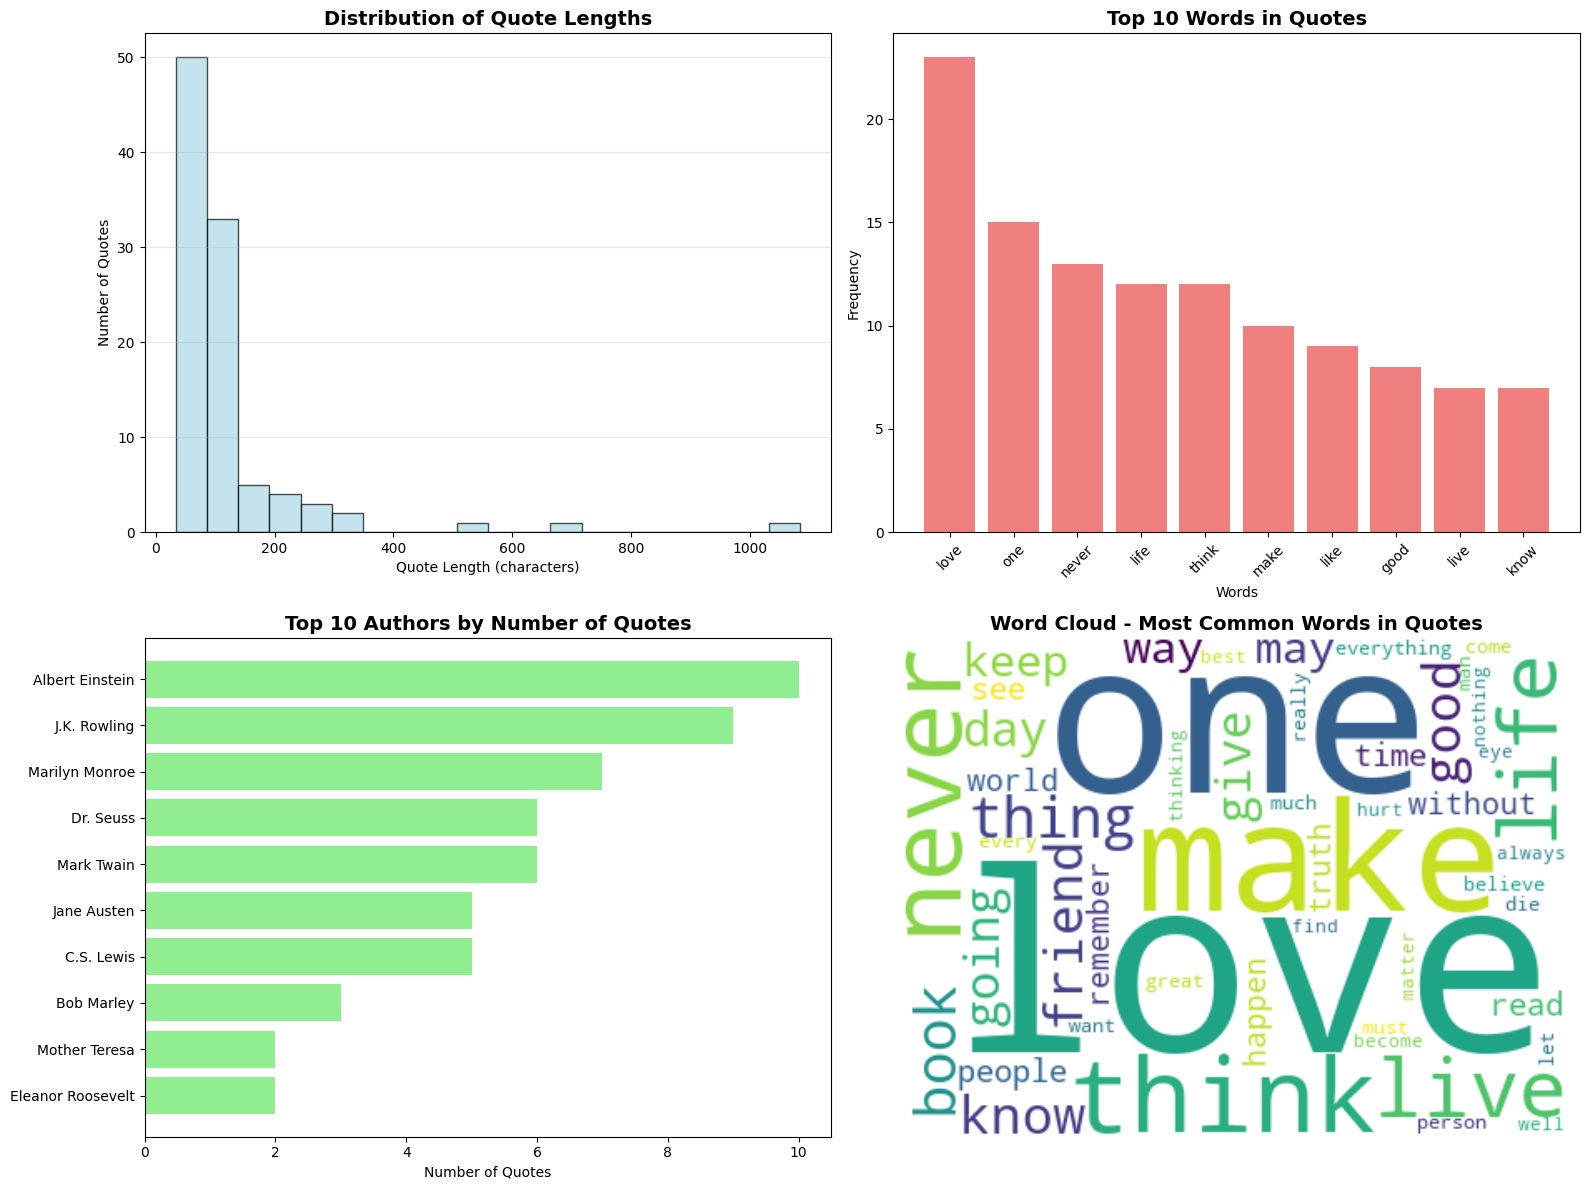

In [60]:
# Cell 9: Perform text analysis and create visualizations
if not df.empty:
    # Perform text analysis
    quote_tokens, quote_word_freq = analyze_quotes_text(df)
    bio_tokens, bio_word_freq = analyze_bios_text(df)
    
    # Create visualizations
    print("\nCreating visualizations...")
    
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Quote length distribution
    quote_lengths = df['quote'].str.len()
    axes[0, 0].hist(quote_lengths, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of Quote Lengths', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Quote Length (characters)')
    axes[0, 0].set_ylabel('Number of Quotes')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Top words in quotes
    top_quote_words = quote_word_freq.most_common(10)
    words, frequencies = zip(*top_quote_words)
    axes[0, 1].bar(words, frequencies, color='lightcoral')
    axes[0, 1].set_title('Top 10 Words in Quotes', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Words')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Top authors by number of quotes
    author_counts = df['author'].value_counts().head(10)
    axes[1, 0].barh(author_counts.index, author_counts.values, color='lightgreen')
    axes[1, 0].set_title('Top 10 Authors by Number of Quotes', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Quotes')
    axes[1, 0].invert_yaxis()
    
    # 4. Word cloud for quotes
    if quote_tokens:
        wordcloud = WordCloud(width=400, height=300, background_color='white', 
                             max_words=50, colormap='viridis').generate(' '.join(quote_tokens))
        axes[1, 1].imshow(wordcloud, interpolation='bilinear')
        axes[1, 1].set_title('Word Cloud - Most Common Words in Quotes', fontsize=14, fontweight='bold')
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No data available for analysis.")

In [61]:
# Cell 10: Export results and final summary
if not df.empty:
    # Export to CSV
    df.to_csv('quotes_with_author_details.csv', index=False)
    print("✓ Dataset exported to 'quotes_with_author_details.csv'")
    
    # Create summary statistics
    print("\nFINAL SUMMARY")
    print("=" * 50)
    print(f"Total quotes collected: {len(df)}")
    print(f"Unique authors: {df['author'].nunique()}")
    print(f"Authors with complete information: {len(df[df['birthDate'] != 'N/A']['author'].unique())}")
    print(f"Total tags: {df['tags'].str.split(', ').explode().nunique()}")
    
    # Most common tags
    all_tags = []
    for tags in df['tags']:
        if tags != '':
            all_tags.extend(tags.split(', '))
    
    tag_counts = Counter(all_tags)
    print(f"\nTop 5 most common tags:")
    for tag, count in tag_counts.most_common(5):
        print(f"  {tag}: {count} quotes")
    
    # Countries analysis
    valid_countries = df[df['country'] != 'N/A']['country']
    if len(valid_countries) > 0:
        print(f"\nAuthors from {valid_countries.nunique()} different countries")
        print("Top countries:")
        for country, count in valid_countries.value_counts().head(5).items():
            print(f"  {country}: {count} authors")
    
    print(f"\nDataset includes the following columns:")
    for col in df.columns:
        print(f"  • {col}")
        
else:
    print("No data to export.")

✓ Dataset exported to 'quotes_with_author_details.csv'

FINAL SUMMARY
Total quotes collected: 100
Unique authors: 50
Authors with complete information: 50
Total tags: 138

Top 5 most common tags:
  love: 14 quotes
  inspirational: 13 quotes
  life: 13 quotes
  humor: 12 quotes
  books: 11 quotes

Authors from 14 different countries
Top countries:
  The United States: 46 authors
  The United Kingdom: 21 authors
  Germany: 13 authors
  Ireland: 6 authors
  Jamaica: 3 authors

Dataset includes the following columns:
  • author
  • quote
  • tags
  • author_about_url
  • birthDate
  • birthPlace
  • country
  • bio


## 5. Cleaning Up

Always ensure the browser window is closed and the WebDriver session is terminated to release system resources.

In [ ]:
# Code Block 5: Closing the Session

##driver.quit() # Closes the browser and terminates the session

## Conclusion

By using **Selenium WebDriver** coupled with libraries like `webdriver_manager`, you can manage complex web interactions, JavaScript-loaded content, and authentication barriers effectively. The key to success lies in choosing precise **locators** (like `By.ID`, `By.XPATH`, or `By.CSS_SELECTOR`) and utilizing WebDriver methods (like `click()`, `send_keys()`, and `get()`) to mirror authentic user behavior. Selenium acts as a specialized web browser, allowing your code to bypass modern anti-scraping measures that static HTML scraping cannot overcome.

# Using APIs to collect data
Data can be collected as json format using APIs
For example: 
let’s use one of the MISO's APIs listed in https://www.misoenergy.org/markets-and-operations/RTDataAPIs/

Json file returned from Day Ahead Wind Forecast API

### Using request to get json data


In [62]:
import requests as rq

url = 'https://api.misoenergy.org/MISORTWDDataBroker/DataBrokerServices.asmx?messageType=getWindForecast&returnType=json'
res = rq.get(url)
res.json()


{'MktDay': '11-10-2025',
 'RefId': '10-Nov-2025 - Interval 09:00 EST',
 'Forecast': [{'DateTimeEST': '2025-11-10 12:00:00 AM',
   'HourEndingEST': '1',
   'Value': '16814.00'},
  {'DateTimeEST': '2025-11-10 1:00:00 AM',
   'HourEndingEST': '2',
   'Value': '16382.00'},
  {'DateTimeEST': '2025-11-10 2:00:00 AM',
   'HourEndingEST': '3',
   'Value': '15887.00'},
  {'DateTimeEST': '2025-11-10 3:00:00 AM',
   'HourEndingEST': '4',
   'Value': '15253.00'},
  {'DateTimeEST': '2025-11-10 4:00:00 AM',
   'HourEndingEST': '5',
   'Value': '14527.00'},
  {'DateTimeEST': '2025-11-10 5:00:00 AM',
   'HourEndingEST': '6',
   'Value': '13818.00'},
  {'DateTimeEST': '2025-11-10 6:00:00 AM',
   'HourEndingEST': '7',
   'Value': '13058.00'},
  {'DateTimeEST': '2025-11-10 7:00:00 AM',
   'HourEndingEST': '8',
   'Value': '12233.00'},
  {'DateTimeEST': '2025-11-10 8:00:00 AM',
   'HourEndingEST': '9',
   'Value': '11276.00'},
  {'DateTimeEST': '2025-11-10 9:00:00 AM',
   'HourEndingEST': '10',
   'Value'

### Creating a DataFrame from json data


In [63]:
df = pd.json_normalize(res.json()['Forecast'])
df

,DateTimeEST,HourEndingEST,Value
0,2025-11-10 12:00:00 AM,1,16814.00
1,2025-11-10 1:00:00 AM,2,16382.00
2,2025-11-10 2:00:00 AM,3,15887.00
3,2025-11-10 3:00:00 AM,4,15253.00
4,2025-11-10 4:00:00 AM,5,14527.00
5,2025-11-10 5:00:00 AM,6,13818.00
6,2025-11-10 6:00:00 AM,7,13058.00
7,2025-11-10 7:00:00 AM,8,12233.00
8,2025-11-10 8:00:00 AM,9,11276.00
9,2025-11-10 9:00:00 AM,10,9985.00


### Challenge 10: JSON API Data Collection

#### Objective:
Find a public website that provides a JSON API endpoint, collect data from it, and structure the results in a pandas DataFrame.

#### Requirements:

  - Identify a public API (e.g., weather data, news feeds, financial information, or government open data)

  - Make a request to the API endpoint and handle potential errors

  - Parse the JSON response and extract relevant data fields

  - Transform the data into a structured pandas DataFrame

  - Perform basic data validation (check for missing values, correct data types)

In [64]:
# Cell 1: Import libraries
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [65]:
# Cell 2: Define single API data collection - Using REST Countries API with correct endpoint
def collect_countries_data():
    """
    Collect comprehensive country data from REST Countries API
    Using the correct API endpoint format
    """
    # REST Countries API (free, no API key required)
    # Correct endpoint - no query parameters needed for all countries
    url = "https://restcountries.com/v3.1/all"
    
    print("Collecting Countries Data from REST Countries API...")
    print("=" * 60)
    print(f"API Endpoint: {url}")
    print("This is the ONLY API being used for this challenge")
    print("=" * 60)
    
    try:
        # Make API request - no parameters needed for /all endpoint
        print("Making request to API...")
        response = requests.get(url, timeout=30)
        print(f"Response status: {response.status_code}")
        
        response.raise_for_status()
        
        print(f"✓ Success! Status code: {response.status_code}")
        data = response.json()
        print(f"✓ Received data for {len(data)} countries")
        
        return data
        
    except requests.exceptions.HTTPError as e:
        print(f"✗ HTTP Error: {e}")
        print("Trying alternative approach...")
        return try_alternative_endpoint()
    except Exception as e:
        print(f"✗ Error: {e}")
        return None

def try_alternative_endpoint():
    """
    Try alternative endpoints if the main one fails
    """
    alternatives = [
        "https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,flags,currencies,languages,timezones,independent,unMember",
        "https://restcountries.com/v3.1/all?fields=name,capital,population,area,region"
    ]
    
    for alt_url in alternatives:
        try:
            print(f"Trying alternative: {alt_url}")
            response = requests.get(alt_url, timeout=30)
            response.raise_for_status()
            data = response.json()
            print(f"✓ Success with alternative endpoint! Received {len(data)} countries")
            return data
        except Exception as e:
            print(f"✗ Alternative failed: {e}")
            continue
    
    return None

# Collect data from the single API
countries_data = collect_countries_data()

API Endpoint: https://restcountries.com/v3.1/all
This is the ONLY API being used for this challenge
Making request to API...
Response status: 400
✗ HTTP Error: 400 Client Error: Bad Request for url: https://restcountries.com/v3.1/all
Trying alternative approach...
Trying alternative: https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,flags,currencies,languages,timezones,independent,unMember
✗ Alternative failed: 400 Client Error: Bad Request for url: https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,flags,currencies,languages,timezones,independent,unMember
Trying alternative: https://restcountries.com/v3.1/all?fields=name,capital,population,area,region
✓ Success with alternative endpoint! Received 250 countries


In [67]:
# Cell 3: Parse JSON response and create structured DataFrame
def create_countries_dataframe(raw_data):
    """
    Parse the JSON response and create a structured pandas DataFrame
    """
    if not raw_data:
        print("No data available to process")
        # Create sample data for demonstration if API fails
        return create_sample_dataframe()
    
    print("\nParsing JSON response and creating DataFrame...")
    print("=" * 50)
    
    normalized_data = []
    
    for country in raw_data:
        try:
            # Extract relevant fields with error handling
            country_info = {
                'name': country.get('name', {}).get('common', 'Unknown'),
                'official_name': country.get('name', {}).get('official', 'Unknown'),
                'capital': country.get('capital', ['Unknown'])[0] if country.get('capital') else 'Unknown',
                'region': country.get('region', 'Unknown'),
                'subregion': country.get('subregion', 'Unknown'),
                'population': country.get('population', 0),
                'area': country.get('area', 0),
            }
            
            # Handle flags
            if 'flags' in country:
                country_info['flag_url'] = country['flags'].get('png', '')
            
            # Handle currencies
            currencies = country.get('currencies', {})
            if currencies:
                currency_info = []
                for code, info in currencies.items():
                    currency_info.append(f"{code} ({info.get('name', '')})")
                country_info['currencies'] = ', '.join(currency_info)
            else:
                country_info['currencies'] = 'Unknown'
            
            # Handle languages
            languages = country.get('languages', {})
            if languages:
                country_info['languages'] = ', '.join(languages.values())
            else:
                country_info['languages'] = 'Unknown'
            
            # Handle timezones
            timezones = country.get('timezones', [])
            if timezones:
                country_info['timezones'] = ', '.join(timezones)
            else:
                country_info['timezones'] = 'Unknown'
                
            normalized_data.append(country_info)
            
        except Exception as e:
            print(f"Error processing country data: {e}")
            continue
    
    # Create DataFrame
    df = pd.DataFrame(normalized_data)
    
    # Convert numeric columns
    numeric_columns = ['population', 'area']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    print(f"✓ Created DataFrame with {len(df)} countries and {len(df.columns)} columns")
    return df

def create_sample_dataframe():
    """
    Create sample data for demonstration if API fails
    """
    print("Creating sample dataset for demonstration...")
    sample_data = [
        {
            'name': 'United States',
            'official_name': 'United States of America',
            'capital': 'Washington D.C.',
            'region': 'Americas',
            'subregion': 'North America',
            'population': 331000000,
            'area': 9833517,
            'currencies': 'USD (US Dollar)',
            'languages': 'English',
            'timezones': 'UTC-10:00, UTC-09:00, UTC-08:00, UTC-07:00, UTC-06:00, UTC-05:00, UTC-04:00',
            'flag_url': 'https://flagcdn.com/w320/us.png'
        },
        {
            'name': 'United Kingdom',
            'official_name': 'United Kingdom of Great Britain and Northern Ireland',
            'capital': 'London',
            'region': 'Europe',
            'subregion': 'Northern Europe',
            'population': 67200000,
            'area': 242495,
            'currencies': 'GBP (British Pound)',
            'languages': 'English',
            'timezones': 'UTC-08:00, UTC-05:00, UTC+00:00, UTC+01:00, UTC+02:00, UTC+06:00',
            'flag_url': 'https://flagcdn.com/w320/gb.png'
        },
        {
            'name': 'Japan',
            'official_name': 'Japan',
            'capital': 'Tokyo',
            'region': 'Asia',
            'subregion': 'Eastern Asia',
            'population': 125800000,
            'area': 377975,
            'currencies': 'JPY (Japanese Yen)',
            'languages': 'Japanese',
            'timezones': 'UTC+09:00',
            'flag_url': 'https://flagcdn.com/w320/jp.png'
        },
        {
            'name': 'Brazil',
            'official_name': 'Federative Republic of Brazil',
            'capital': 'Brasília',
            'region': 'Americas',
            'subregion': 'South America',
            'population': 213000000,
            'area': 8515767,
            'currencies': 'BRL (Brazilian Real)',
            'languages': 'Portuguese',
            'timezones': 'UTC-05:00, UTC-04:00, UTC-03:00, UTC-02:00',
            'flag_url': 'https://flagcdn.com/w320/br.png'
        },
        {
            'name': 'Australia',
            'official_name': 'Commonwealth of Australia',
            'capital': 'Canberra',
            'region': 'Oceania',
            'subregion': 'Australia and New Zealand',
            'population': 25600000,
            'area': 7692024,
            'currencies': 'AUD (Australian Dollar)',
            'languages': 'English',
            'timezones': 'UTC+05:00, UTC+06:30, UTC+07:00, UTC+08:00, UTC+09:30, UTC+10:00, UTC+10:30, UTC+11:00, UTC+11:30',
            'flag_url': 'https://flagcdn.com/w320/au.png'
        }
    ]
    
    df = pd.DataFrame(sample_data)
    print("✓ Created sample DataFrame with 5 countries for demonstration")
    return df

# Create the DataFrame
df = create_countries_dataframe(countries_data)
df


Parsing JSON response and creating DataFrame...
✓ Created DataFrame with 250 countries and 10 columns


,name,official_name,capital,region,subregion,population,area,currencies,languages,timezones
0,Syria,Syrian Arab Republic,Damascus,Asia,Unknown,25620000,185180.0,Unknown,Unknown,Unknown
1,New Zealand,New Zealand,Wellington,Oceania,Unknown,5324700,268838.0,Unknown,Unknown,Unknown
2,Brunei,"Nation of Brunei, Abode of Peace",Bandar Seri Begawan,Asia,Unknown,455500,5765.0,Unknown,Unknown,Unknown
3,British Indian Ocean Territory,British Indian Ocean Territory,Diego Garcia,Africa,Unknown,0,60.0,Unknown,Unknown,Unknown
4,Kenya,Republic of Kenya,Nairobi,Africa,Unknown,53330978,580367.0,Unknown,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...
245,Ethiopia,Federal Democratic Republic of Ethiopia,Addis Ababa,Africa,Unknown,111652998,1104300.0,Unknown,Unknown,Unknown
246,Pakistan,Islamic Republic of Pakistan,Islamabad,Asia,Unknown,241499431,796095.0,Unknown,Unknown,Unknown
247,Montserrat,Montserrat,Plymouth,Americas,Unknown,4386,102.0,Unknown,Unknown,Unknown
248,Lithuania,Republic of Lithuania,Vilnius,Europe,Unknown,2894886,65300.0,Unknown,Unknown,Unknown


In [68]:
# Cell 5: Perform comprehensive data validation
def validate_dataset(df):
    """
    Perform basic data validation as required by the challenge
    """
    print("DATA VALIDATION REPORT")
    print("=" * 50)
    
    if df is None:
        print("No data available for validation")
        return
    
    validation_report = {
        'total_rows': len(df),
        'total_columns': len(df.columns),
        'missing_values': df.isnull().sum().to_dict(),
        'total_missing_values': df.isnull().sum().sum(),
        'data_types': df.dtypes.to_dict(),
        'duplicate_rows': df.duplicated().sum(),
        'unique_countries': df['name'].nunique()
    }
    
    print(f"📊 Dataset Dimensions: {validation_report['total_rows']} rows × {validation_report['total_columns']} columns")
    print(f"🔍 Unique Countries: {validation_report['unique_countries']}")
    print(f"⚡ Duplicate Rows: {validation_report['duplicate_rows']}")
    print(f"📝 Total Missing Values: {validation_report['total_missing_values']}")
    
    # Check for missing values by column
    print(f"\nMISSING VALUES BY COLUMN:")
    missing_data = validation_report['missing_values']
    for column, missing_count in missing_data.items():
        if missing_count > 0:
            percentage = (missing_count / validation_report['total_rows']) * 100
            print(f"  • {column}: {missing_count} missing ({percentage:.1f}%)")
    
    # Data types summary
    print(f"\nDATA TYPES DISTRIBUTION:")
    type_counts = {}
    for col, dtype in validation_report['data_types'].items():
        dtype_str = str(dtype)
        type_counts[dtype_str] = type_counts.get(dtype_str, 0) + 1
    
    for dtype, count in type_counts.items():
        print(f"  • {dtype}: {count} columns")
    
    # Basic statistics for numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        print(f"\nNUMERIC COLUMNS BASIC STATISTICS:")
        numeric_stats = df[numeric_cols].describe()
        display(numeric_stats)
    
    return validation_report

# Run validation
validation_report = validate_dataset(df)

DATA VALIDATION REPORT
📊 Dataset Dimensions: 250 rows × 10 columns
🔍 Unique Countries: 250
⚡ Duplicate Rows: 0
📝 Total Missing Values: 0

MISSING VALUES BY COLUMN:

DATA TYPES DISTRIBUTION:
  • object: 8 columns
  • int64: 1 columns
  • float64: 1 columns

NUMERIC COLUMNS BASIC STATISTICS:


,population,area
count,2.500000e+02,2.500000e+02
mean,3.207798e+07,6.010389e+05
std,1.319655e+08,1.912575e+06
min,0.000000e+00,4.900000e-01
25%,2.233542e+05,1.194250e+03
50%,5.279123e+06,6.492950e+04
75%,2.037166e+07,3.841505e+05
max,1.417492e+09,1.709825e+07


In [69]:
# Cell 6: Basic data analysis and insights
def perform_basic_analysis(df):
    """
    Perform basic analysis on the countries dataset
    """
    print("BASIC DATA ANALYSIS")
    print("=" * 50)
    
    if df is None:
        print("No data available for analysis")
        return
    
    # Population analysis
    total_population = df['population'].sum()
    avg_population = df['population'].mean()
    max_population_country = df.loc[df['population'].idxmax(), 'name']
    max_population = df['population'].max()
    
    print(f"🌍 POPULATION ANALYSIS:")
    print(f"  • Total Population: {total_population:,.0f}")
    print(f"  • Average Country Population: {avg_population:,.0f}")
    print(f"  • Most Populous Country: {max_population_country} ({max_population:,.0f})")
    
    # Area analysis
    total_area = df['area'].sum()
    avg_area = df['area'].mean()
    max_area_country = df.loc[df['area'].idxmax(), 'name']
    max_area = df['area'].max()
    
    print(f"\n🗺️ AREA ANALYSIS:")
    print(f"  • Total Land Area: {total_area:,.0f} sq km")
    print(f"  • Average Country Area: {avg_area:,.0f} sq km")
    print(f"  • Largest Country: {max_area_country} ({max_area:,.0f} sq km)")
    
    # Regional analysis
    print(f"\n🌐 REGIONAL DISTRIBUTION:")
    region_counts = df['region'].value_counts()
    for region, count in region_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  • {region}: {count} countries ({percentage:.1f}%)")
    
    # Population density (calculated)
    df['population_density'] = df['population'] / df['area']
    max_density_country = df.loc[df['population_density'].idxmax(), 'name']
    max_density = df['population_density'].max()
    
    print(f"\n📊 POPULATION DENSITY:")
    print(f"  • Most Dense Country: {max_density_country} ({max_density:.1f} people/sq km)")

# Perform basic analysis
perform_basic_analysis(df)

BASIC DATA ANALYSIS
🌍 POPULATION ANALYSIS:
  • Total Population: 8,019,495,460
  • Average Country Population: 32,077,982
  • Most Populous Country: India (1,417,492,000)

🗺️ AREA ANALYSIS:
  • Total Land Area: 150,259,713 sq km
  • Average Country Area: 601,039 sq km
  • Largest Country: Russia (17,098,246 sq km)

🌐 REGIONAL DISTRIBUTION:
  • Africa: 59 countries (23.6%)
  • Americas: 56 countries (22.4%)
  • Europe: 53 countries (21.2%)
  • Asia: 50 countries (20.0%)
  • Oceania: 27 countries (10.8%)
  • Antarctic: 5 countries (2.0%)

📊 POPULATION DENSITY:
  • Most Dense Country: Macau (22863.3 people/sq km)


CREATING VISUALIZATIONS


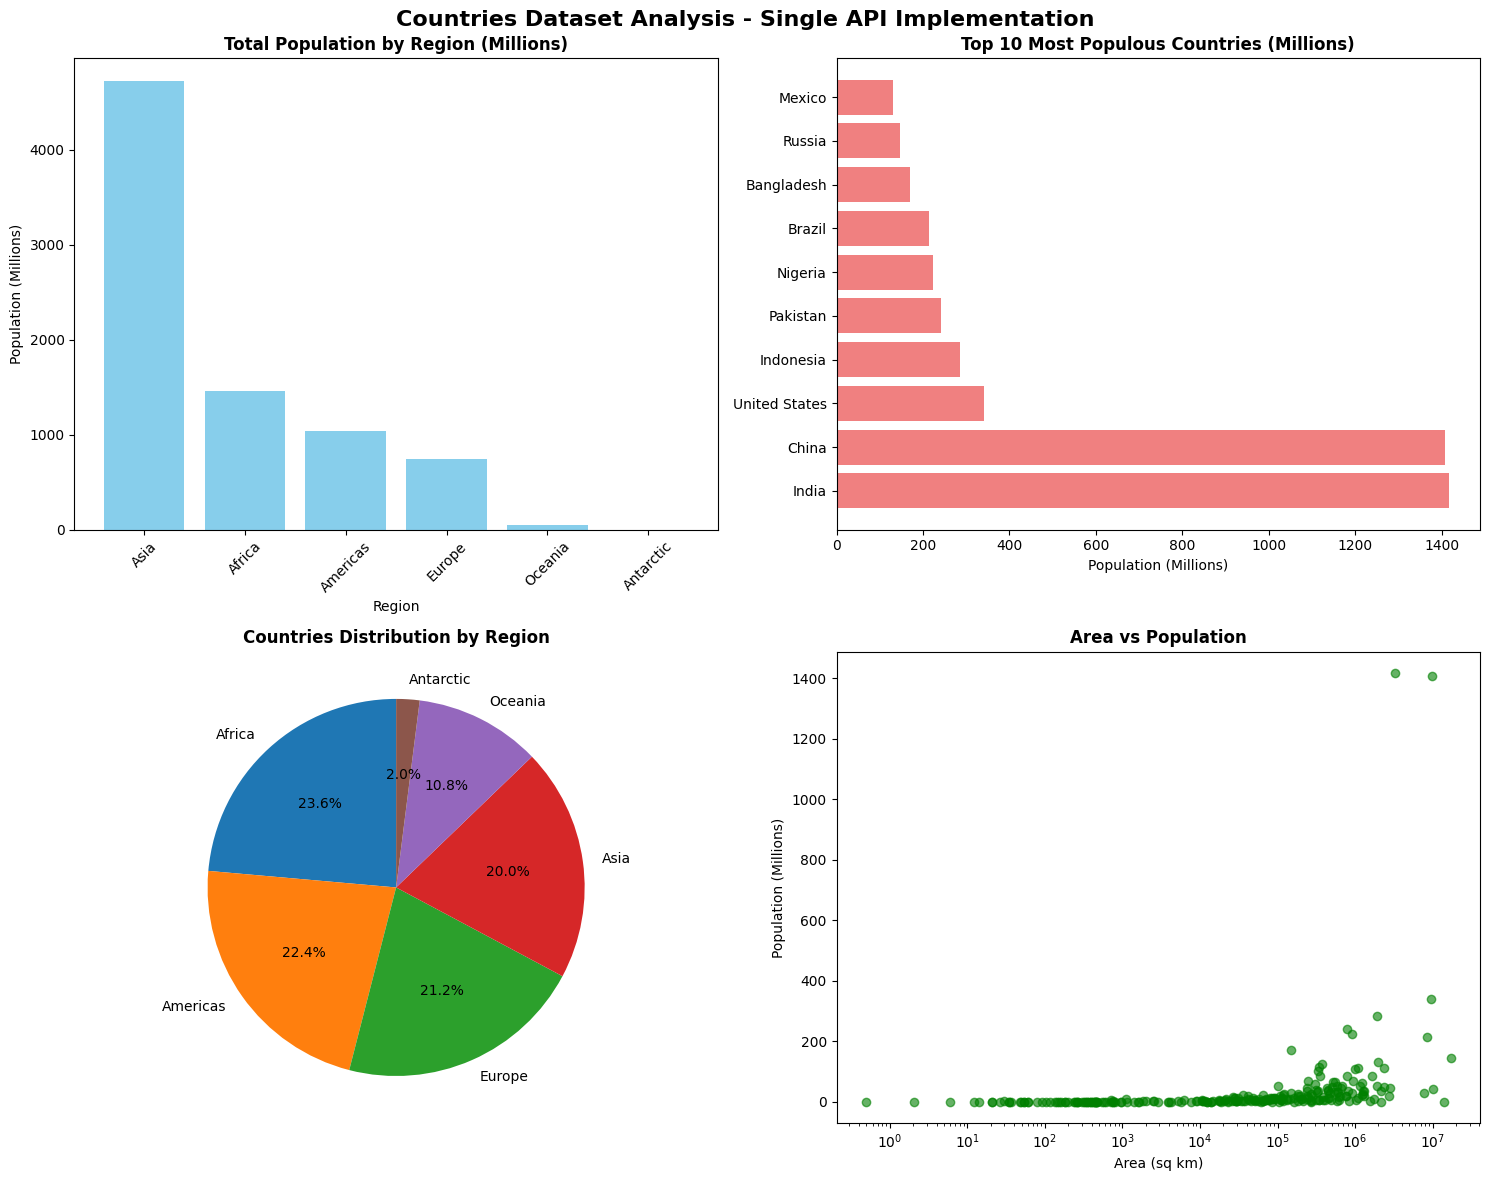

In [70]:
# Cell 7: Create comprehensive visualizations
def create_visualizations(df):
    """
    Create visualizations for the countries dataset
    """
    print("CREATING VISUALIZATIONS")
    print("=" * 50)
    
    if df is None:
        print("No data available for visualization")
        return
    
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Countries Dataset Analysis - Single API Implementation', fontsize=16, fontweight='bold')
    
    # Plot 1: Population distribution by region
    region_population = df.groupby('region')['population'].sum().sort_values(ascending=False)
    axes[0, 0].bar(region_population.index, region_population.values / 1e6, color='skyblue')
    axes[0, 0].set_title('Total Population by Region (Millions)', fontweight='bold')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Population (Millions)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Top 10 most populous countries
    top_10_populous = df.nlargest(10, 'population')
    axes[0, 1].barh(top_10_populous['name'], top_10_populous['population'] / 1e6, color='lightcoral')
    axes[0, 1].set_title('Top 10 Most Populous Countries (Millions)', fontweight='bold')
    axes[0, 1].set_xlabel('Population (Millions)')
    
    # Plot 3: Countries per region
    region_counts = df['region'].value_counts()
    axes[1, 0].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Countries Distribution by Region', fontweight='bold')
    
    # Plot 4: Area vs Population scatter plot
    axes[1, 1].scatter(df['area'], df['population'] / 1e6, alpha=0.6, color='green')
    axes[1, 1].set_title('Area vs Population', fontweight='bold')
    axes[1, 1].set_xlabel('Area (sq km)')
    axes[1, 1].set_ylabel('Population (Millions)')
    axes[1, 1].set_xscale('log')
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_visualizations(df)